### Import libraries

In [1]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import seaborn as sns
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from datetime import datetime, timezone
from scipy.stats import beta, linregress
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.model_selection import ParameterGrid
import torch
import torch.nn as nn
import time
from tqdm import tqdm
import os
import json
import glob
import warnings
import itertools
import gc
import optuna
from optuna.samplers import TPESampler
from dateutil.relativedelta import relativedelta

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU Name; {torch.cuda.get_device_name(0)}")

    warnings.filterwarnings("ignore")

Using Device: cpu


### Data Preparation Function

In [ ]:
def download_btc_data(start_year, end_year, timeframe, symbol = 'BTC/USDT'):
    """
    Args:
        start_year (int): 시작 연도
        end_year (int): 종료 연도
        timeframe (str): 데이터 간격 ('1m', '10m' ,'1d')
        symbol (str): 코인 심볼 (기본 BTC/USDT)
    """

    save_dir = "data"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"[INFO] Directory '{save_dir}' created")

    # Create Binance object
    binance = ccxt.binance({
        'enableRateLimit': True,
        'options': {'defaultType': 'future'}
    })

    # Check wheather Binance support timeframe
    if timeframe not in binance.timeframes:
        print(f"[ERROR] '{timeframe} is not a valid timeframe")
        return

    print(f"Target: {symbol} | Timeframe: {timeframe} | Period: {start_year} ~ {end_year}")

    safe_symbol = symbol.replace("/", "")

    for year in range(start_year, end_year + 1):
        # Set file path including data folder
        filename = f"{safe_symbol}_{timeframe}_{year}.csv"
        file_path = os.path.join(save_dir, filename)

        # Check file existence
        if os.path.exists(file_path):
            print(f"[SKIP] '{filename}' already exists")
            continue

        print(f"\n[INFO] Downloading Year: {year}")
        start_date = datetime(year, 1, 1, 0, 0, 0, tzinfo = timezone.utc)
        end_date = datetime(year + 1, 1, 1, 0, 0, 0, tzinfo = timezone.utc)

        since = int(start_date.timestamp() * 1000)
        end_timestamp = int(end_date.timestamp() * 1000)

        year_ohlcvs = []

        approx_counts = {
            '1m': 525600, '1d': 365 # 10m Data Not Support in Binance API
        }
        total_candles = approx_counts.get(timeframe, 10000)

        pbar = tqdm(total = total_candles, desc = f"{year} Progress", unit = "candle")

        while since < end_timestamp:
            try:
                ohlcvs = binance.fetch_ohlcv(symbol, timeframe = timeframe, since = since, limit = 1000)

                if not ohlcvs:
                    break

                year_ohlcvs.extend(ohlcvs)

                current_last_time = ohlcvs[-1][0]
                since = current_last_time + 1

                pbar.update(len(ohlcvs))

                if current_last_time >= end_timestamp:
                    break

                time.sleep(0.05)

            except Exception as e:
                print(f"[ERROR] {e}, Retryung")
                time.sleep(3)
                continue

        pbar.close()

        if year_ohlcvs:
            df = pd.DataFrame(year_ohlcvs, columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume'])
            df['datetime'] = pd.to_datetime(df['timestamp'], unit = 'ms', utc = True)

            df = df[(df['datetime'] >= start_date) & (df['datetime'] < end_date)]

            df.set_index('datetime', inplace = True)
            df.drop(columns = ['timestamp'], inplace = True)

            df.to_csv(file_path)
            print(f"[SUCCESS] Saved {file_path} (Rows: {len(df)})")
        else:
            print(f"[FAIL] No data for {year}")

def resample_to_10m(start_year, end_year, symbol = 'BTC/USDT'):
    """
    Transform 1m data to 10m data and store to csv file
    """
    save_dir = "data"
    safe_symbol = symbol.replace("/", "")

    print(f"Starting Resampling: {symbol} (1m -> 10m) | {start_year} ~ {end_year}")

    for year in range(start_year, end_year + 1):
        input_filename = f"{safe_symbol}_1m_{year}.csv"
        input_path = os.path.join(save_dir, input_filename)

        output_filename = f"{safe_symbol}_10m_{year}.csv"
        output_path = os.path.join(save_dir, output_filename)

        if not os.path.exists(input_path):
            print(f"[SKIP] Source file not found: {input_filename}")
            continue

        if os.path.exists(output_path):
            print(f"[SKIP] Target file already exists: {output_filename}")
            continue

        print(f"\n[PROCESSING] {input_filename} -> {output_filename}")

        try:
            df = pd.read_csv(input_path)
            df['datetime'] = pd.to_datetime(df['datetime'])
            df.set_index('datetime', inplace = True)

            ohlcv_dict = {
                'open': 'first',
                'high': 'max',
                'low': 'min',
                'close': 'last',
                'volume': 'sum'
            }

            df_10m = df.resample('10min').apply(ohlcv_dict)

            df_10m.dropna(inplace = True)

            df_10m.to_csv(output_path)
            print(f"[DONE] Saved {output_filename} (Rows: {len(df_10m)})")

        except Exception as e:
            print(f"[ERROR] Failed to process {year}: {e}")

In [3]:
# Prepare BTC Data for 1m, 1d, 10m
download_btc_data(2020, 2024, timeframe = '1m')
download_btc_data(2020, 2024, timeframe = '1d')
resample_to_10m(2020, 2024)

Target: BTC/USDT | Timeframe: 1m | Period: 2020 ~ 2024
[SKIP] 'BTCUSDT_1m_2020.csv' already exists
[SKIP] 'BTCUSDT_1m_2021.csv' already exists
[SKIP] 'BTCUSDT_1m_2022.csv' already exists
[SKIP] 'BTCUSDT_1m_2023.csv' already exists
[SKIP] 'BTCUSDT_1m_2024.csv' already exists
Target: BTC/USDT | Timeframe: 1d | Period: 2020 ~ 2024
[SKIP] 'BTCUSDT_1d_2020.csv' already exists
[SKIP] 'BTCUSDT_1d_2021.csv' already exists
[SKIP] 'BTCUSDT_1d_2022.csv' already exists
[SKIP] 'BTCUSDT_1d_2023.csv' already exists
[SKIP] 'BTCUSDT_1d_2024.csv' already exists
Starting Resampling: BTC/USDT (1m -> 10m) | 2020 ~ 2024
[SKIP] Target file already exists: BTCUSDT_10m_2020.csv
[SKIP] Target file already exists: BTCUSDT_10m_2021.csv
[SKIP] Target file already exists: BTCUSDT_10m_2022.csv
[SKIP] Target file already exists: BTCUSDT_10m_2023.csv
[SKIP] Target file already exists: BTCUSDT_10m_2024.csv


### MF-DFA Function

In [ ]:
def mfdfa(data_array, scales, q_list, poly_order = 2):
    """
    Fuction for MFDFA by using Pytorch

    Args:
        batch_data: (Batch_Size, Window_Size) tensor
    """
    if isinstance(data_array, torch.Tensor):
        data_array = data_array.detach().cpu().numpy()
    elif isinstance(data_array, (pd.DataFrame, pd.Series)):
        data_array = data_array.values
    data_array = np.array(data_array)

    if data_array.ndim == 1:
        data_array = data_array.reshape(1, -1)

    batch_size, N = data_array.shape
    profile = np.cumsum(data_array - np.mean(data_array, axis = 1, keepdims = True), axis = 1)

    F_q_s = []
    valid_scales = []

    for s in scales:
        if N // s < 4: continue
        valid_scales.append(s)
        N_s = N // s

        seg_f = profile[:, :N_s*s].reshape(batch_size, N_s, s)
        seg_b = profile[:, -N_s*s:].reshape(batch_size, N_s, s)
        segments = np.concatenate([seg_f, seg_b], axis = 1)

        x_axis = np.linspace(-1, 1, s)

        X_design = np.vstack([x_axis**i for i in range(poly_order+1)]).T
        pinv_X = np.linalg.pinv(X_design)

        beta = np.matmul(segments, pinv_X.T)
        trend = np.matmul(beta, X_design.T)

        resid = segments - trend
        F2 = np.mean(resid**2, axis = 2)
        F2 = np.maximum(F2, 1e-20)

        F_vals = []
        for q in q_list:
            if abs(q) < 1e-5:
                f_q = np.exp(0.5 * np.mean(np.log(F2), axis = 1))
            else:
                f_q = np.mean(F2**(q/2), axis = 1)**(1/q)
            F_vals.append(f_q)

        F_q_s.append(np.stack(F_vals, axis = 1))

    if not F_q_s: return None, None

    F_output = np.stack(F_q_s, axis = 2)

    return np.array(valid_scales), F_output

def mfdfa_features(price_series, device, window, step):
    print(f"[INFO] Extracting MFDFA Features (Window: {window})")

    if isinstance(price_series, pd.DataFrame):
        price_series = price_series.iloc[:, 0]

    log_ret = np.log(price_series / price_series.shift(1)).dropna()
    values = log_ret.values

    windows = []
    indices = []

    BATCH_SIZE =   64
    feature_list = []

    q_list = np.linspace(-5, 5, 15)
    scales = np.unique(np.logspace(np.log10(10), np.log10(window//4), 10).astype(int))

    for t in tqdm(range(window, len(values), step)):
        seg = values[t-window : t]
        windows.append(seg)
        indices.append(log_ret.index[t])

        if len(windows) >= BATCH_SIZE:
            batch_tensor = torch.tensor(np.array(windows), dtype = torch.float32).to(device)
            s_vals, F_tensor = mfdfa(batch_tensor, scales, q_list)

            if F_tensor is not None:
                F_np = F_tensor
                log_s = np.log(s_vals)

                for i in range(len(F_np)):
                    h_q = []
                    for i_q in range(len(q_list)):
                        slope, _, _, _, _ = linregress(log_s, np.log(F_np[i, i_q, :]))
                        h_q.append(slope)

                    h_q = np.array(h_q)
                    delta_H = np.max(h_q) - np.min(h_q)
                    q_arr = np.array(q_list)
                    tau = q_arr * h_q - 1
                    alpha = np.gradient(tau, q_arr)

                    delta_alpha = np.max(alpha) - np.min(alpha)
                    alpha_0 = alpha[len(q_list)//2]

                    feature_list.append([delta_H, delta_alpha, alpha_0])

            windows = []
    if len(feature_list) != len(indices):
        min_len = min(len(feature_list), len(indices))
        feature_list = feature_list[:min_len]
        indices = indices[:min_len]

    return pd.DataFrame(feature_list, columns = ['delta_H', 'delta_alpha', 'alpha_0'], index = indices).dropna()

def compute_spectrum(price_series, q_list):
    log_ret = np.log(price_series / price_series.shift(1)).dropna()
    values = log_ret.values

    N = len(values)
    min_scale = 30
    max_scale = N // 10
    scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 30).astype(int))

    s_vals, F_batch = mfdfa(values, scales, q_list, poly_order = 2)

    if F_batch is None: return None

    F_np = F_batch[0]
    log_s = np.log(s_vals)
    h_q = []

    for i_q in range(len(q_list)):
        slope, _, _, _, _ = linregress(log_s, np.log(F_np[i_q, :]))
        h_q.append(slope)

    h_q = np.array(h_q)
    delta_H = np.max(h_q) - np.min(h_q)
    q_arr = np.array(q_list)
    tau = q_arr * h_q - 1
    alpha = np.gradient(tau, q_arr)
    delta_alpha = np.max(alpha) - np.min(alpha)
    f_alpha = q_arr * alpha - tau
    alpha_0 = alpha[len(q_list)//2]

    return{
        'scales': s_vals, 'F_q_s': F_np, 'H_q': h_q,
        'tau_q': tau, 'alpha': alpha, 'f_alpha': f_alpha,
        'delta_H': delta_H, 'delta_alpha': delta_alpha,
        'alpha_0': alpha_0
    }

### AI Model

In [ ]:
# 새로운 RV를 정의 (OHLCV 기반)
def ohlcv_rv(df, window = 144):
    T = window
    kappa = 1.34

    k = (kappa - 1) / (kappa + (T + 1) / (T - 1))

    o_t = np.log(df['open'] / df['close'].shift(1))

    c_t = np.log(df['close'] / df['open'])

    rsy = (np.log(df['high'] / df['close']) * np.log(df['high'] / df['open']) + \
           np.log(df['low'] / df['close']) * np.log(df['low'] / df['open']))
    
    sigma_o = o_t.rolling(window = T).var()
    sigma_c = c_t.rolling(window = T).var()

    sigma_rsy = rsy.rolling(window = T).mean()

    daily_variance = (sigma_o + k * sigma_c + (1 - k) * sigma_rsy) * T

    df['RV_OHLCV'] = np.sqrt(daily_variance)
    
    return df

class AsymmetricResidualLoss(nn.Module):
    def __init__(self, penalty_weight = 3.0):
        super(AsymmetricResidualLoss, self).__init__()
        self.penalty = penalty_weight
        
    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        loss = torch.where(error > 0, (error * self.penalty)**2, error ** 2)
        return loss.mean()

class FlattenLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim = 64, num_layers = 2, dropout = 0.0):
        super(FlattenLSTM, self).__init__()
        eff_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True, dropout = eff_dropout)
        self.attention = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Tanh())
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(out), dim = 1)
        context = torch.sum(attn_weights * out, dim = 1)
        return self.fc(context)

class FlattenBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim = 64, num_layers = 2, dropout = 0.0):
        super(FlattenBiLSTM, self).__init__()        
        eff_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first = True,
            dropout = eff_dropout,
            bidirectional = True
        )        
        self.attention = nn.Sequential(nn.Linear(hidden_dim * 2, 1), nn.Tanh())
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)
        return self.fc(context)

class FlattenGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim = 64, num_layers = 2, dropout = 0.0):
        super(FlattenGRU, self).__init__()
        eff_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first = True, dropout = eff_dropout)
        self.attention = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Tanh())
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)
        return self.fc(context)
    
class FlattenBiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim = 64, num_layers = 2, dropout = 0.0):
        super(FlattenBiGRU, self).__init__()
        eff_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers,
            batch_first = True, bidirectional = True, dropout = eff_dropout
        )
        self.attention = nn.Sequential(nn.Linear(hidden_dim * 2, 1), nn.Tanh())
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)
        return self.fc(context)

def prepare_flatten_features(df_base, mfdfa_df, lags=144):
    print(f"Data Preprocessing: Creating Lags={lags} (Safe & Optimized)")

    # ---------------------------------------------------------
    # 1. MF-DFA 전처리
    # ---------------------------------------------------------
    if df_base.index.tz is not None: df_base.index = df_base.index.tz_localize(None)
    
    mfdfa_cols = ['delta_H', 'delta_alpha', 'alpha_0']
    mfdfa_subset = mfdfa_df[mfdfa_cols].copy()

    if mfdfa_subset.index.tz is not None: mfdfa_subset.index = mfdfa_subset.index.tz_localize(None)


    mfdfa_daily = mfdfa_subset.resample('1D').last()

    mfdfa_daily.index = pd.to_datetime(mfdfa_daily.index).normalize()

    mfdfa_shifted = mfdfa_daily.shift(1)

    # ---------------------------------------------------------
    # 2. 데이터 병합
    # ---------------------------------------------------------
    df_base['date_key'] = df_base.index.normalize()

    merged_data = pd.merge(df_base, mfdfa_shifted,
                           left_on='date_key', right_index=True,
                           how='left')

    merged_data.drop(columns=['date_key'], inplace=True)

    merged_data[mfdfa_cols] = merged_data[mfdfa_cols].fillna(method='ffill')

    # ---------------------------------------------------------
    # 3. 변수 생성 및 메모리 최적화
    # ---------------------------------------------------------
    merged_data['Future_Vol_24h'] = merged_data['RV_OHLCV'].shift(-144)

    merged_data['Base_Vol'] = merged_data['gm_vol'].fillna(method='ffill')
    
    # merged_data['Target_Residual'] = merged_data['Future_Vol_24h'] - (merged_data['Base_Vol'])
    merged_data['Target_Residual'] = np.log((merged_data['Future_Vol_24h'] / merged_data['Base_Vol']))
    
    merged_data['Past_GARCH_RV'] = merged_data['Base_Vol']
    merged_data['Past_Residual'] = np.log((merged_data['RV_OHLCV'] / merged_data['Base_Vol']))

    cols_needed = ['Target_Residual', 'Base_Vol', 'Future_Vol_24h', 
                   'RV_OHLCV', 'return', 'Past_Residual'] + mfdfa_cols
    data = merged_data[cols_needed].copy()

    # float32 변환 (메모리 절약)
    for col in data.select_dtypes(include=['float64']).columns:
        data[col] = data[col].astype('float32')

    data.dropna(inplace=True)

    # ---------------------------------------------------------
    # 4. Lag Feature 생성
    # ---------------------------------------------------------
    base_features = ['RV_OHLCV', 'return', 'Past_Residual'] + mfdfa_cols
    feature_dfs = [data]
    all_feature_cols = []

    for lag in tqdm(range(1, lags + 1), desc="Generating Lags"):
        shifted = data[base_features].shift(lag)
        shifted.columns = [f"{col}_lag{lag}" for col in base_features]
        feature_dfs.append(shifted)
        all_feature_cols.extend(shifted.columns)

    del merged_data, mfdfa_shifted, mfdfa_daily
    gc.collect()

    data_final = pd.concat(feature_dfs, axis=1)
    data_final.dropna(inplace=True)

    print(f"Final Data shape: {data_final.shape}")

    return data_final, all_feature_cols


### GARCH-MIDAS Model

In [ ]:
def get_beta_weights(K, w1, w2):
    k_vals = np.linspace(1e-6, 1.0 - 1e-6, K)
    weights = k_vals**(w1 - 1) * (1 - k_vals)**(w2 - 1)
    return weights / weights.sum()

def garch_midas(train_df, test_df, daily_rv, df_x, midas_k = 30):
    print("[INFO] Running GARCH-MIDAS")

    full_df = pd.concat([train_df, test_df])

    train_end_idx = train_df.index[-1]

    daily_rv_scaled = daily_rv.copy()
    if daily_rv_scaled['rv'].mean() < 0.1:
        daily_rv_scaled['rv'] = daily_rv_scaled['rv'] * 10000

    combined_daily = pd.merge(daily_rv_scaled[['rv']], df_x, left_index = True, right_index = True, how = 'inner')

    weights = get_beta_weights(midas_k, 1.0, 5.0)

    combined_daily['midas_rv'] = combined_daily['rv'].rolling(midas_k).apply(
        lambda x: np.dot(x, weights[::-1]), raw = True
    ).shift(1)

    x_col_name = df_x.columns[0]
    combined_daily['exog_x'] = combined_daily[x_col_name].rolling(midas_k).apply(
        lambda x: np.dot(x, weights[::-1]), raw = True
    ).shift(1)

    combined_daily.dropna(inplace = True)

    merged = full_df.join(combined_daily[['midas_rv', 'exog_x']], how = 'left')
    merged[['midas_rv', 'exog_x']] = merged[['midas_rv', 'exog_x']].fillna(method='ffill')
    merged.dropna(inplace=True)

    if merged['return'].abs().mean() < 0.1:
        merged['return_scaled'] = merged['return'] * 100
    else:
        merged['return_scaled'] = merged['return']

    mask_train = merged.index <= train_end_idx

    train_ret = merged.loc[mask_train, 'return_scaled'].values
    train_midas = merged.loc[mask_train, 'midas_rv'].values
    train_exog = merged.loc[mask_train, 'exog_x'].values
    T_train = len(train_ret)


    def objective(params):
        alpha, beta, m, theta, beta_x = params

        if alpha + beta >= 0.999 or alpha < 0 or beta < 0:
            return 1e10

        tau = (m**2) + (theta**2 * train_midas) + (beta_x**2 * train_exog)
        tau = np.maximum(tau, 1e-12)

        g = np.ones(T_train)
        e2_over_tau = (train_ret**2) / tau
        omega = (1 - alpha - beta)

        g[0] = 1.0
        for t in range(1, T_train):
            g[t] = omega + alpha * e2_over_tau[t-1] + beta * g[t-1]

        h = tau * g
        llh = 0.5 * (np.log(2 * np.pi) + np.log(h) + (train_ret**2) / h)
        return np.sum(llh)

    initial_guess = [0.05, 0.90, 0.1, 0.3, 0.1]
    bounds = [(0, 1), (0, 1), (None, None), (None, None), (None, None)]

    try:
        res = minimize(objective, initial_guess, method = 'L-BFGS-B', bounds = bounds)
        best_params = res.x
        success = res.success
        msg = res.message
    except:
        best_params = initial_guess
        success = False
        msg = "Optimization Crash"

    alpha, beta, m ,theta, beta_x = best_params

    full_ret = merged['return_scaled'].values
    full_midas = merged['midas_rv'].values
    full_exog = merged['exog_x'].values
    T_full = len(full_ret)

    tau_full = (m**2) + (theta**2 * full_midas) + (beta_x**2 * full_exog)
    tau_full = np.maximum(tau_full, 1e-12)

    g_full = np.ones(T_full)
    e2_over_tau_full = (full_ret**2) / tau_full
    omega = (1 - alpha - beta)

    for t in range(1, T_full):
        g_full[t] = omega + alpha * e2_over_tau_full[t-1] + beta * g_full[t-1]

    merged['gm_vol'] = np.sqrt(tau_full * g_full)

    mask_test = merged.index > train_end_idx
    test_result = merged.loc[mask_test].copy()

    print("-" * 40)
    print(f"[DEBUG] Optimization Result: {msg} (Success: {success})")
    print(f"[DEBUG] Best Parameters:")
    print(f"   - Alpha (GARCH) : {alpha:.6f}")
    print(f"   - Beta  (GARCH) : {beta:.6f}")
    print(f"   - m     (Const) : {m:.6f}  -> (m^2 used: {m**2:.8f})")
    print(f"   - Theta (RV_Wgt): {theta:.6f}  -> (theta^2 used: {theta**2:.8f})")
    print(f"   - W_Exog({x_col_name}): {beta_x:.6f}  -> (w^2 used: {beta_x**2:.8f})")

    print(f"[DEBUG] Predicted RV (gm_vol) Stats (Test Period):")
    if len(test_result) > 0:
        print(f"   - Mean: {test_result['gm_vol'].mean():.6f}")
        print(f"   - Min : {test_result['gm_vol'].min():.6f}")
        print(f"   - Max : {test_result['gm_vol'].max():.6f}")
        print(f"   - First 5 values: {test_result['gm_vol'].values[:5]}")
    else:
        print("   - [Warning] Test result is empty.")
    print("-" * 60)

    return test_result

def monthly_garch_midas(df_target, mfdfa_df, exog_col = None, midas_k = 30):
    """
    Predict Realized Volatility by using Base Model (GARCH_MIDAS)
    Don't use future data, use past data to estimate parameters
    """
    print(f"[INFO] Base Model Running (Exog: {exog_col if exog_col else 'None'})")

    monthly_results = []

    month_starts = df_target.resample('MS').first().index

    min_train_month = 2

    daily_rv_all = (df_target['return']**2).resample('1D').sum().to_frame('rv')

    mfdfa_df.index = pd.to_datetime(mfdfa_df.index).normalize()

    if exog_col is None:
        df_x_full = pd.DataFrame(0, index = mfdfa_df.index, columns = ['exog_x'])
    else:
        if exog_col not in mfdfa_df.columns:
            raise KeyError(f"Not Exist '{exog_col}' column in MF-DFA data")
        df_x_full = mfdfa_df[[exog_col]].copy()
        df_x_full.columns = ['exog_x']

    df_x_full = df_x_full.resample('1D').mean()

    print(f"   -> RV 데이터 기간: {daily_rv_all.index.min()} ~ {daily_rv_all.index.max()}")
    print(f"   -> MF-DFA 데이터 기간: {df_x_full.index.min()} ~ {df_x_full.index.max()}")

    # 교집합 확인
    common_idx = daily_rv_all.index.intersection(df_x_full.index)
    print(f"   -> 겹치는 날짜 수: {len(common_idx)}일")

    if len(common_idx) < 100:
        raise ValueError(f"데이터 날짜가 서로 안 맞습니다! 겹치는 날짜가 {len(common_idx)}개 뿐입니다.")

    df_x_full = df_x_full.reindex(daily_rv_all.index).fillna(method = 'ffill').fillna(0)

    pbar = tqdm(range(min_train_month, len(month_starts)), desc = "Monthly Re-fitting")

    for i in pbar:
        current_month = month_starts[i]
        next_month = month_starts[i + 1] if i+1 < len(month_starts) else None

        train_slice = df_target[:current_month]

        if next_month:
            test_slice = df_target[current_month:next_month]
        else:
            test_slice = df_target[current_month:]

        try:
            pred_df = garch_midas(
                train_slice, test_slice, daily_rv_all, df_x_full, midas_k
            )
            monthly_results.append(pred_df)
        except Exception as e:
            print(f"\n Error at {current_month.strftime('%Y-%m')}: {e}")
            pass

    if len(monthly_results) > 0:
        final_gm_df = pd.concat(monthly_results).sort_index()
        print(f"Complete {len(final_gm_df)} Created")
        return final_gm_df
    else:
        raise ValueError("No result by Failing GARCH0-MDIAS Model Training")

def garch_midas_tuned(train_df, test_df, daily_rv, df_x, midas_k = 30):

    full_df = pd.concat([train_df, test_df])

    train_end_idx = train_df.index[-1]
    
    daily_rv_scaled = daily_rv.copy()
    daily_rv_scaled['rv'] = daily_rv_scaled['rv'] * 10000

    combined_daily = pd.merge(daily_rv_scaled[['rv']], df_x, left_index = True, right_index = True, how = 'inner')

    weights = get_beta_weights(midas_k, 1.0, 5.0)

    combined_daily['midas_rv'] = combined_daily['rv'].rolling(midas_k).apply(
        lambda x: np.dot(x, weights[::-1]), raw = True
    ).shift(1)

    x_col_name = df_x.columns[0]
    combined_daily['exog_x'] = combined_daily[x_col_name].rolling(midas_k).apply(
        lambda x: np.dot(x, weights[::-1]), raw = True
    ).shift(1)

    combined_daily.dropna(inplace = True)

    merged = full_df.copy()
    merged['date_key'] = merged.index.normalize()
    combined_daily.index = combined_daily.index.normalize()
    
    merged = merged.merge(combined_daily[['midas_rv', 'exog_x']], left_on='date_key', right_index=True, how='left')
    merged.drop(columns=['date_key'], inplace=True)
    
    merged[['midas_rv', 'exog_x']] = merged[['midas_rv', 'exog_x']].fillna(method='ffill')
    merged.dropna(inplace=True)

    merged['return_scaled'] = merged['return']

    mask_train = merged.index <= train_end_idx

    train_ret = merged.loc[mask_train, 'return_scaled'].values
    train_midas = merged.loc[mask_train, 'midas_rv'].values
    train_exog = merged.loc[mask_train, 'exog_x'].values
    T_train = len(train_ret)

    def objective(params):
        alpha, beta, m, theta, beta_x = params

        if alpha + beta >= 0.999 or alpha < 0 or beta < 0:
            return 1e10

        tau = (m**2) + (theta**2 * train_midas) + (beta_x**2 * train_exog)
        tau = np.maximum(tau, 1e-12)
        
        tau_10m = tau / 144.0

        g = np.ones(T_train)
        e2_over_tau = (train_ret**2) / tau_10m
        omega = (1 - alpha - beta)

        g[0] = 1.0
        for t in range(1, T_train):
            g[t] = omega + alpha * e2_over_tau[t-1] + beta * g[t-1]

        h = tau_10m * g
        llh = 0.5 * (np.log(2 * np.pi) + np.log(h) + (train_ret**2) / h)
        return np.sum(llh)

    initial_guess = [0.05, 0.90, 0.1, 0.3, 0.1]
    bounds = [(0, 1), (0, 1), (None, None), (None, None), (None, None)]

    try:
        res = minimize(objective, initial_guess, method = 'L-BFGS-B', bounds = bounds)
        best_params = res.x
        msg = res.message
        success = res.success
    except Exception as e:
        best_params = initial_guess
        msg = f"Optimization Failed: {str(e)}"
        success = False

    alpha, beta, m ,theta, beta_x = best_params

    full_ret = merged['return_scaled'].values
    full_midas = merged['midas_rv'].values
    full_exog = merged['exog_x'].values
    T_full = len(full_ret)

    tau_full = (m**2) + (theta**2 * full_midas) + (beta_x**2 * full_exog)
    tau_full = np.maximum(tau_full, 1e-12)
    tau_full_10m = tau_full / 144.0

    g_full = np.ones(T_full)
    e2_over_tau_full = (full_ret**2) / tau_full_10m
    omega = (1 - alpha - beta)

    for t in range(1, T_full):
        g_full[t] = omega + alpha * e2_over_tau_full[t-1] + beta * g_full[t-1]

    merged['gm_vol'] = (np.sqrt(tau_full_10m * g_full) / 100) * 12

    mask_test = merged.index >= (train_end_idx - pd.Timedelta(days = 1))
    test_result = merged.loc[mask_test].copy()
    
    print("-" * 40)
    print(f"[DEBUG] Optimization Result: {msg} (Success: {success})")
    print(f"[DEBUG] Best Parameters:")
    print(f"   - Alpha (GARCH) : {alpha:.6f}")
    print(f"   - Beta  (GARCH) : {beta:.6f}")
    print(f"   - m     (Const) : {m:.6f}  -> (m^2 used: {m**2:.8f})")
    print(f"   - Theta (RV_Wgt): {theta:.6f}  -> (theta^2 used: {theta**2:.8f})")
    print(f"   - W_Exog({x_col_name}): {beta_x:.6f}  -> (w^2 used: {beta_x**2:.8f})")

    print(f"[DEBUG] Predicted RV (gm_vol) Stats (Test Period):")
    if len(test_result) > 0:
        print(f"   - Mean: {test_result['gm_vol'].mean():.6f}")
        print(f"   - Min : {test_result['gm_vol'].min():.6f}")
        print(f"   - Max : {test_result['gm_vol'].max():.6f}")
        print(f"   - First 5 values: {test_result['gm_vol'].values[:5]}")
    else:
        print("   - [Warning] Test result is empty.")
    print("-" * 60)

    return merged


Found 5 files
  -> Loaded 2020
  -> Loaded 2021
  -> Loaded 2022
  -> Loaded 2023
  -> Loaded 2024

 Running MFDFA
   -> Analyzed Merged (5 Years)
   -> Analyzed 2020
   -> Analyzed 2021
   -> Analyzed 2022
   -> Analyzed 2023
   -> Analyzed 2024


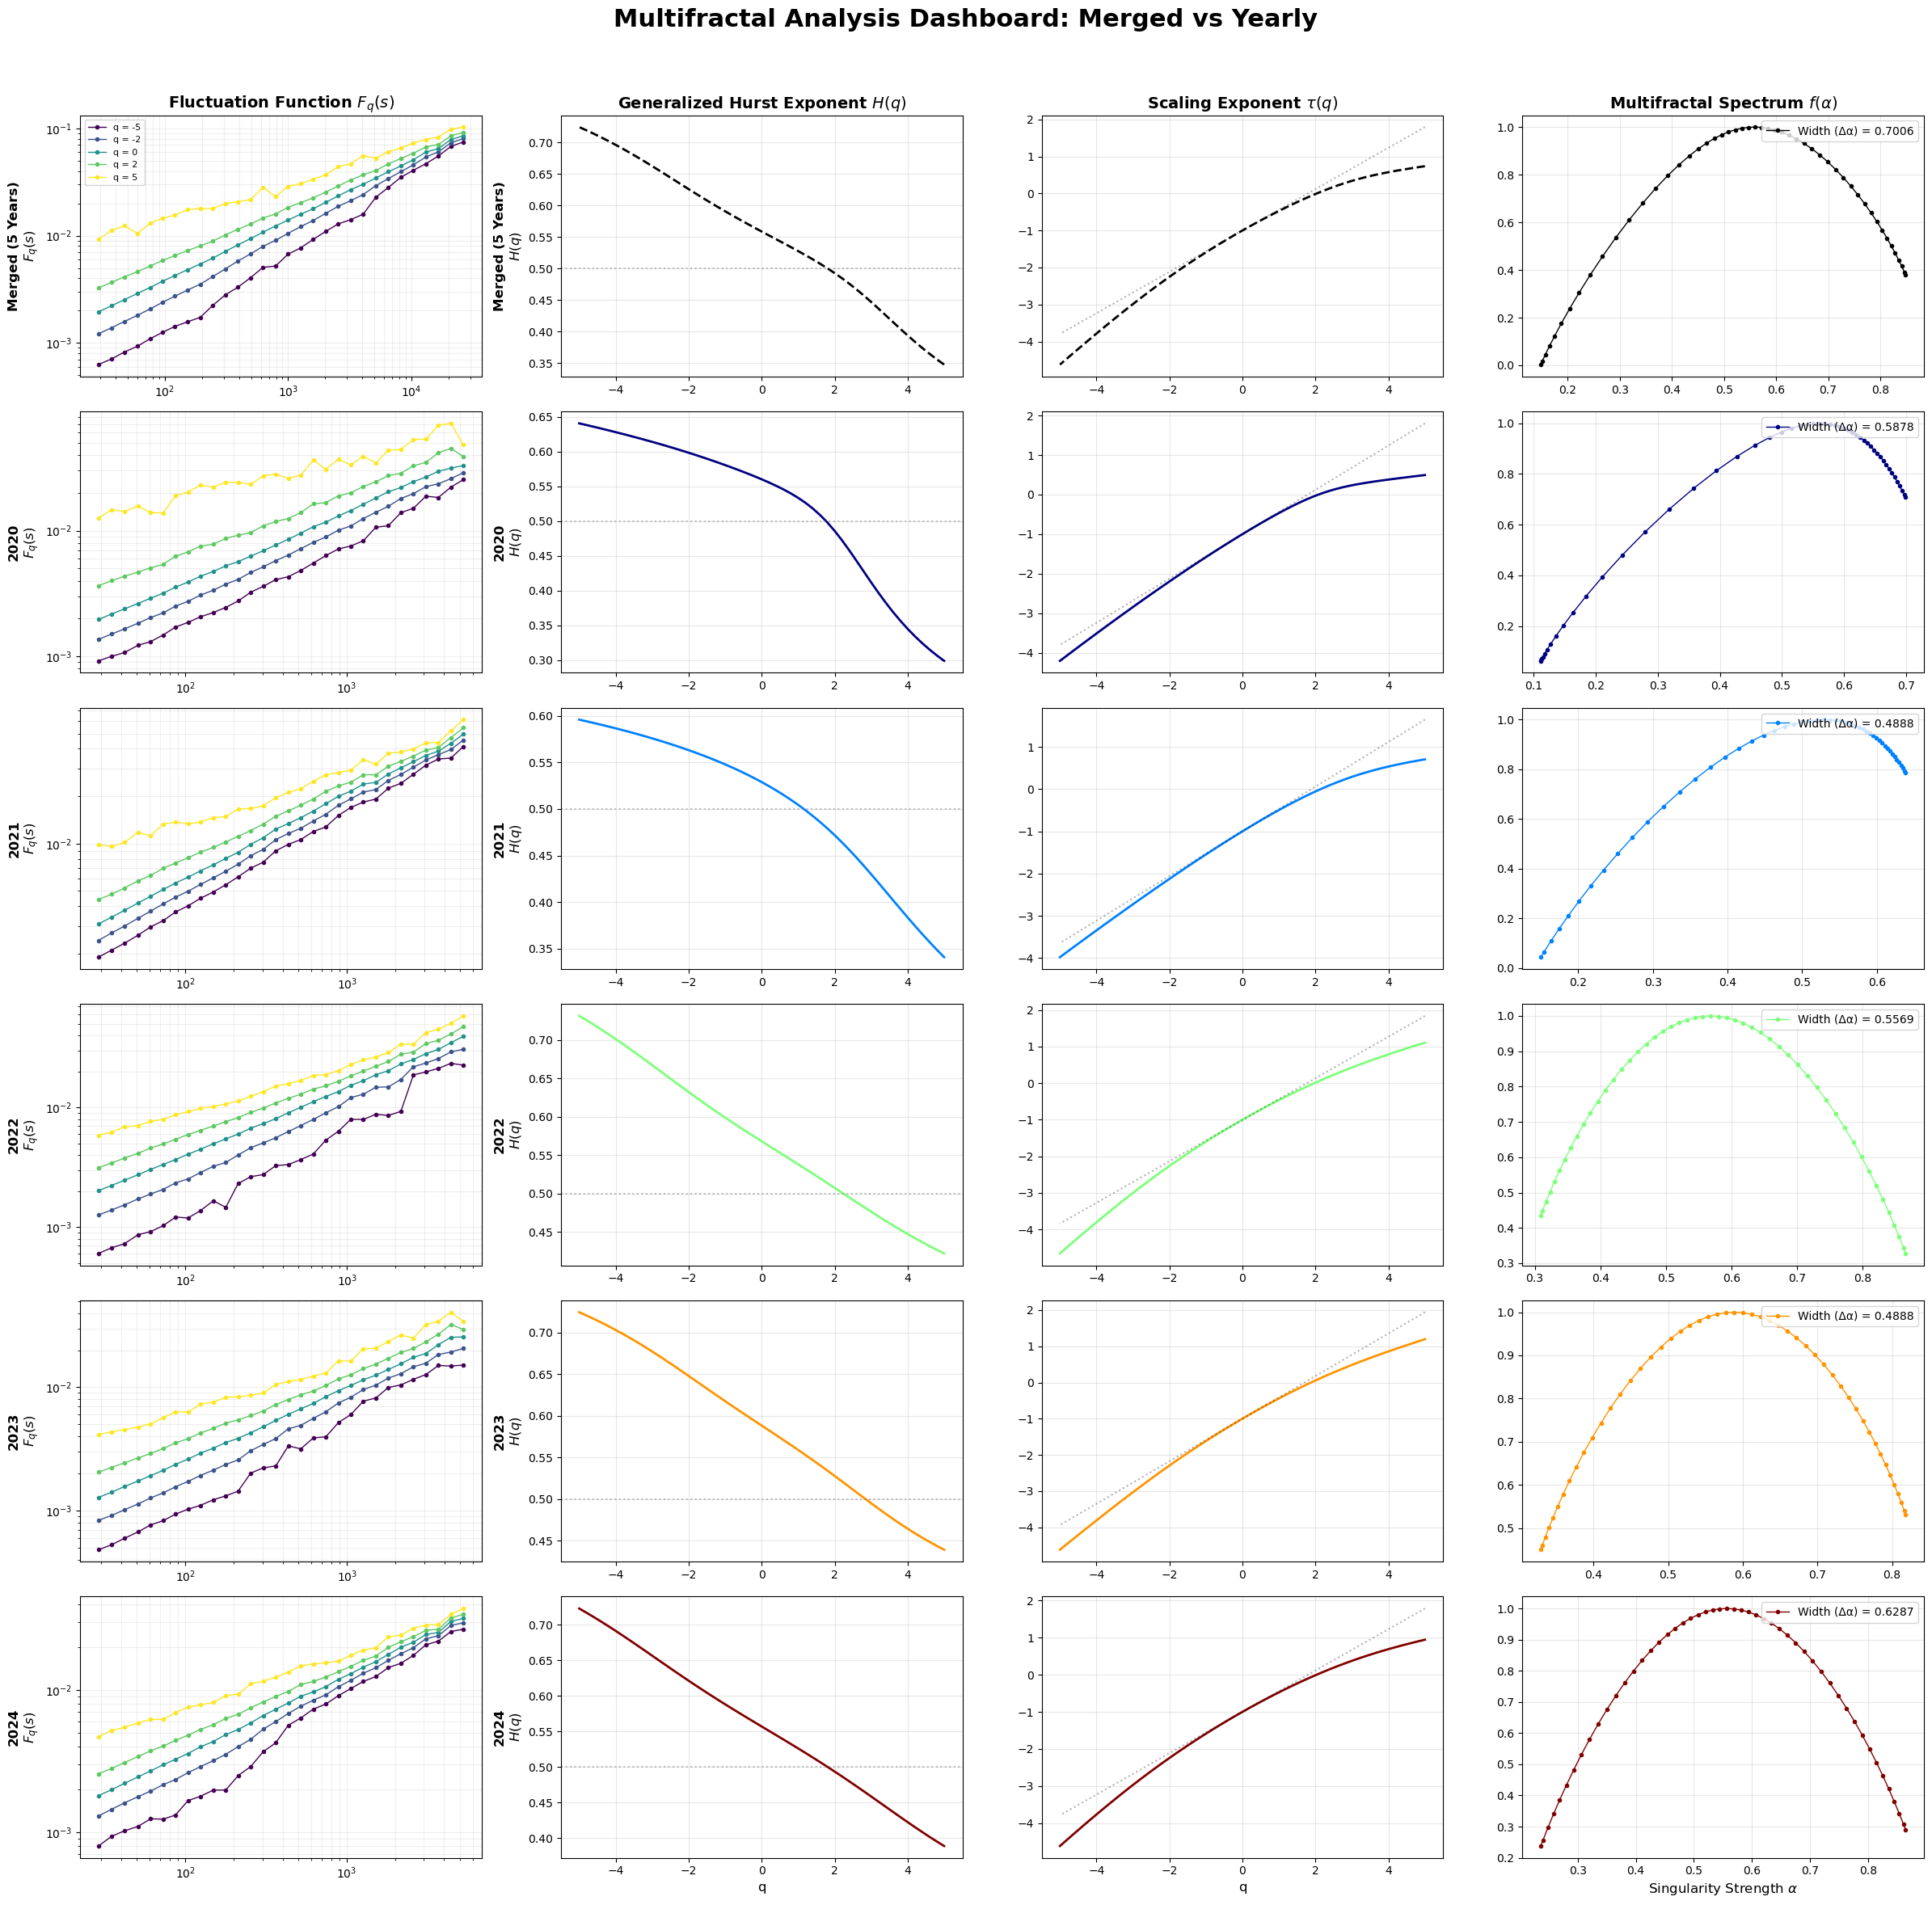

In [7]:
data_dir = "data"
files = sorted(glob.glob(os.path.join(data_dir, "BTCUSDT_10m_*.csv")))

if not files:
    print("No data")
else:
    print(f"Found {len(files)} files")

datasets = {}

for f in files:
    df = pd.read_csv(f, index_col = 'datetime', parse_dates = True)
    if 'return' not in df.columns:
        df['return'] = np.log(df['close']).diff()
    df.dropna(inplace = True)

    year = str(df.index.year[0])
    datasets[year] = df['close']
    print(f"  -> Loaded {year}")

df_all = pd.concat([pd.read_csv(f, index_col = 'datetime', parse_dates = True) for f in files]).sort_index()
if 'return' not in df_all.columns: df_all['return'] = np.log(df_all['close']).diff()
df_all.dropna(inplace = True)
datasets['Merged (5 Years)'] = df_all['close']

keys = sorted([k for k in datasets.keys() if 'Merged' not in k])
keys.insert(0, 'Merged (5 Years)')

q_list = np.linspace(5, -5, 51)
results = {}

print("\n Running MFDFA")
for name in keys:
    res = compute_spectrum(datasets[name], q_list)
    if res: results[name] = res
    print(f"   -> Analyzed {name}")
fig, axes = plt.subplots(len(keys), 4, figsize=(24, 24))

    # 전체 제목
plt.subplots_adjust(top=0.95, wspace = 0.3, hspace = 0.4)
fig.suptitle('Multifractal Analysis Dashboard: Merged vs Yearly', fontsize=22, fontweight='bold')

    # 색상 맵 (Merged는 검정, 연도는 다채롭게)
cmap = plt.cm.jet(np.linspace(0, 1, len(keys)-1))
q_plots = [-5, -2, 0, 2, 5]
colors_q = plt.cm.viridis(np.linspace(0, 1, len(q_plots)))

for i, name in enumerate(keys):
    res = results[name]

        # 색상 설정
    if 'Merged' in name:
        color = 'black'
        style = '--'
    else:
        color = cmap[i-1]
        style = '-'

    ax0 = axes[i, 0]
    for j, qv in enumerate(q_plots):
        idx = np.argmin(np.abs(q_list - qv))
        ax0.loglog(res['scales'], res['F_q_s'][idx, :], 'o-',
                   color = colors_q[j], markersize = 3, linewidth = 1, label = f'q = {qv}')

    ax0.grid(True, which = 'both', alpha = 0.2)
    ax0.set_ylabel(f"{name}\n$F_q(s)$", fontsize = 12, fontweight = 'bold')

    if i == 0:
        ax0.set_title("Fluctuation Function $F_q(s)$", fontsize = 14, fontweight = 'bold')
        ax0.legend(fontsize = 8, loc = 'upper left')

        # --- (Col 1) H(q) ---
    ax1 = axes[i, 1]
    ax1.plot(q_list, res['H_q'], linestyle=style, color=color, linewidth=2)
    ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel(f"{name}\n$H(q)$", fontsize=12, fontweight='bold')
    if i == 0: ax1.set_title("Generalized Hurst Exponent $H(q)$", fontsize=14, fontweight='bold')

        # --- (Col 2) tau(q) ---
    ax2 = axes[i, 2]
    ax2.plot(q_list, res['tau_q'], linestyle=style, color=color, linewidth=2)

        # Monofractal Reference Line (비교용 점선)
    h2 = res['H_q'][len(q_list)//2] # q=0 근처의 H값 사용
    ax2.plot(q_list, q_list * h2 - 1, 'k:', alpha=0.3, label='Linear Fit')

    ax2.grid(True, alpha=0.3)
    if i == 0: ax2.set_title("Scaling Exponent $\\tau(q)$", fontsize=14, fontweight='bold')

        # --- (Col 3) f(alpha) ---
    ax3 = axes[i, 3]
        # 스펙트럼 너비(Width) 표시
    label_txt = f"Width (Δα) = {res['delta_alpha']:.4f}"
    ax3.plot(res['alpha'], res['f_alpha'], 'o-', markersize=3, color=color, linewidth=1, label=label_txt)

    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right', fontsize=10, frameon=True)
    if i == 0: ax3.set_title("Multifractal Spectrum $f(\\alpha)$", fontsize=14, fontweight='bold')

        # X축 라벨은 맨 마지막 행에만 표시
    if i == len(keys) - 1:
        ax1.set_xlabel('q', fontsize=12)
        ax2.set_xlabel('q', fontsize=12)
        ax3.set_xlabel('Singularity Strength $\\alpha$', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
# 2020 ~ 2024년도 데이터 load
# mfdfa, 10분봉 데이터 모두 딕셔너리로 변환해 저장
# 특정 연도의 데이터를 사용할 때는 dfs_10m[*], mfdfas[*]로 사용

dfs_10m = {}
dfs_1d = {}
mfdfas = {}

years = range(2020, 2025)
WINDOW_SIZE = 30 * 144

print("="*30)
print("5 Years Data Load & Start Calculation MF-DFA")
print("="*30)

for year in years:
  print(f"\n[{year}] Data Processing")

  path_10m = f"data/BTCUSDT_10m_{year}.csv"
  path_1d = f"data\BTCUSDT_1d_{year}.csv"

  try:
    df = pd.read_csv(path_10m)
    df.columns = [c.lower().strip() for c in df.columns]

    date_col = None
    for col in ['timestamp', 'date', 'datetime', 'open_time']:
      if col in df.columns:
        date_col = col
        break

    if date_col:
      df[date_col] = pd.to_datetime(df[date_col])
      df.set_index(date_col, inplace = True)
    else:
      raise KeyError("Can't find date columns")

    if 'return' not in df.columns:
      df['return'] = np.log(df['close']).diff() * 100

    df.dropna(inplace = True)

    dfs_10m[year] = df
    print(f"-> Loaded data. Shape: {df.shape} | Range: {df.index.min().date()} ~ {df.index.max().date()}")

    print(f"-> Calculating MF-DFA")
    mfdfa_df = mfdfa_features(df['close'], DEVICE, window = WINDOW_SIZE, step = 1)

    mfdfas[year] = mfdfa_df
    print(f"-> Complete Calculation of MF-DFA: {mfdfa_df.shape}")
  except FileNotFoundError:
    print(f"[Error] {path_10m} file Not Found")

  except Exception as e:
    print(f"[Error]: {e}")
  
  try:
    df_daily = pd.read_csv(path_1d)
    df_daily.columns = [c.lower().strip() for c in df_daily.columns]
    
    date_col_1d = None
    for col in ['timestamp', 'date', 'datetime', 'open_time']:
      if col in df_daily.columns:
        date_col_1d = col
        break
    
    if date_col_1d:
      df_daily[date_col_1d] = pd.to_datetime(df_daily[date_col_1d])
      df_daily.set_index(date_col_1d, inplace=True)
    else:
      raise KeyError("Can't find date columns in 1D data")

    if 'return' not in df_daily.columns:
      df_daily['return'] = np.log(df_daily['close']).diff() * 100

    df_daily.dropna(inplace=True)

    dfs_1d[year] = df_daily
    print(f"-> [1D]  Loaded data. Shape: {df_daily.shape} | Range: {df_daily.index.min().date()} ~ {df_daily.index.max().date()}")
        
  except FileNotFoundError:
    print(f"[Error] {path_1d} file Not Found")
  except Exception as e:
    print(f"[Error] 1D data processing: {e}")
    
print("\n" + "="*30)
print("5 Years Data Load & Complete Calculation MF-DFA")
print("="*30)


for year in years:
  if year in dfs_10m and year in mfdfas:
    globals()[f"df_10m_{year}"] = dfs_10m[year]
    globals()[f"mfdfa_{year}"] = mfdfas[year]
  if year in dfs_1d:
    globals()[f"df_1d_{year}"] = dfs_1d[year]
    
  print(f"Variable Allocation Complete: df_10m_{year}, mfdfa_{year}")

# 모든 연도에 대한 딕셔너리를 변수에 저장하는 로직
# 해당 로직을 수행한 이후 원하는 연도의 변수를 함수의 인자로 받아서 연도별 예측 실행


print("="*30)

print("Merge All range Data")

if dfs_10m:
  df_10m_all = pd.concat(dfs_10m.values()).sort_index()
  print(f"-> All 10 intraday Shape: {df_10m_all.shape}")
  
if mfdfas:
  mfdfa_all = pd.concat(mfdfas.values()).sort_index()
  print(f"-> All MF-DFA Shape: {mfdfa_all.shape}")
  
if dfs_1d:
  df_1d_all = pd.concat(dfs_1d.values()).sort_index()
  print(f"-> All 1-Day intraday Shape: {df_1d_all.shape}")

print("Complete Merging")
print("="*30)

5 Years Data Load & Start Calculation MF-DFA

[2020] Data Processing
-> Loaded data. Shape: (52703, 6) | Range: 2020-01-01 ~ 2020-12-31
-> Calculating MF-DFA
[INFO] Extracting MFDFA Features (Window: 4320)


100%|██████████| 48382/48382 [05:30<00:00, 146.26it/s]


-> Complete Calculation of MF-DFA: (48320, 3)
-> [1D]  Loaded data. Shape: (365, 6) | Range: 2020-01-02 ~ 2020-12-31

[2021] Data Processing
-> Loaded data. Shape: (52559, 6) | Range: 2021-01-01 ~ 2021-12-31
-> Calculating MF-DFA
[INFO] Extracting MFDFA Features (Window: 4320)


100%|██████████| 48238/48238 [05:13<00:00, 154.00it/s]


-> Complete Calculation of MF-DFA: (48192, 3)
-> [1D]  Loaded data. Shape: (364, 6) | Range: 2021-01-02 ~ 2021-12-31

[2022] Data Processing
-> Loaded data. Shape: (52559, 6) | Range: 2022-01-01 ~ 2022-12-31
-> Calculating MF-DFA
[INFO] Extracting MFDFA Features (Window: 4320)


...

-> Complete Calculation of MF-DFA: (48192, 3)
-> [1D]  Loaded data. Shape: (364, 6) | Range: 2022-01-02 ~ 2022-12-31

[2023] Data Processing
-> Loaded data. Shape: (52559, 6) | Range: 2023-01-01 ~ 2023-12-31
-> Calculating MF-DFA
[INFO] Extracting MFDFA Features (Window: 4320)


100%|██████████| 48238/48238 [04:37<00:00, 173.70it/s]


-> Complete Calculation of MF-DFA: (48192, 3)
-> [1D]  Loaded data. Shape: (364, 6) | Range: 2023-01-02 ~ 2023-12-31

[2024] Data Processing
-> Loaded data. Shape: (52703, 6) | Range: 2024-01-01 ~ 2024-12-31
-> Calculating MF-DFA
[INFO] Extracting MFDFA Features (Window: 4320)


100%|██████████| 48382/48382 [04:41<00:00, 172.17it/s]

-> Complete Calculation of MF-DFA: (48320, 3)
-> [1D]  Loaded data. Shape: (365, 6) | Range: 2024-01-02 ~ 2024-12-31

5 Years Data Load & Complete Calculation MF-DFA
Variable Allocation Complete: df_10m_2020, mfdfa_2020
Variable Allocation Complete: df_10m_2021, mfdfa_2021
Variable Allocation Complete: df_10m_2022, mfdfa_2022
Variable Allocation Complete: df_10m_2023, mfdfa_2023
Variable Allocation Complete: df_10m_2024, mfdfa_2024
Merge All range Data
-> All 10 intraday Shape: (263083, 6)
-> All MF-DFA Shape: (241216, 3)
-> All 1-Day intraday Shape: (1822, 6)
Complete Merging


### 실험 1. Scaler 변경
- 기존에 사용하던 MinMaxScaler를 사용시 GARCH-MIDAS + AI 모델들의 Min과 Max 값이 실제 값과 엄청난 차이가 발생
- MinMaxScaler를 사용하여 scaling을 진행했기 때문에 Standard Scaler로 실험 <br>
**파라미터는 다음과 같이 고정**
- alpha = 1.0
- hidden_dim = 64
- num_layers = 2
- learning_rate = 0.002
- midas_k = 7

### 실험 2. Loss Function 변경
- 기존에 사용하던 HuberLoss가 아닌 Asymmetric Loss를 사용
- loss 함수가 계산하는 error = (실제 RV - GARCH 예측 RV) - AI 모델의 잔차 예측
  - error = y_true - y_pred

In [ ]:
BASELINE_PARAMS = {
    "Ridge": {"alpha": 1.0},
    "LSTM": {"hidden_dim": 64, "num_layers": 2, "learning_rate": 0.002},
    "BI-LSTM": {"hidden_dim": 64, "num_layers": 2, "learning_rate": 0.002},
    "GRU": {"hidden_dim": 64, "num_layers": 2, "learning_rate": 0.002},
    "BI-GRU": {"hidden_dim": 64, "num_layers": 2, "learning_rate": 0.002},
    "GARCH_K": 30
}

def run_oos_simulation_for_month(df_period, test_start, feature_cols, model_name, params, scenario_type, dropout_rate = 0.0):
    is_daily = 'Daily' in scenario_type
    is_hybrid = 'Hybrid' in scenario_type
    
    train_len = len(df_period[df_period.index < test_start])
    
    ROLL_WINDOW = 7 if is_daily else train_len
    UPDATE_FREQ = 144
    DELAY = 1 if is_daily else 144
    
    
    target_col = 'Target_Residual' if is_hybrid else 'Future_Vol_24h'
    y_full = df_period[[target_col]].values
    
    if is_hybrid:
        base_vol_test = (df_period['Base_Vol_24h']).values[train_len:]
    
    X_full = df_period[feature_cols].values
        
    safe_train_end = train_len - DELAY
    scaler_X = StandardScaler().fit(X_full[:safe_train_end])
    scaler_y = StandardScaler().fit(y_full[:safe_train_end])
    
    X_scaled = scaler_X.transform(X_full)
    y_scaled = scaler_y.transform(y_full)
    
    is_dl = model_name != 'Ridge'
    lags = 144
    
    if is_dl:
        num_features = len(feature_cols)
        
        X_3d = np.zeros((len(X_scaled), lags, num_features))
        for i in range(lags - 1, len(X_scaled)):
            X_3d[i] = X_scaled[i - lags + 1 : i + 1]
                
        X_tensor = torch.FloatTensor(X_3d).to(DEVICE)
        y_tensor = torch.FloatTensor(y_scaled).to(DEVICE)
        input_dim = num_features
        
        if model_name == 'LSTM': model = FlattenLSTM(input_dim, params['hidden_dim'], params['num_layers'], dropout=dropout_rate).to(DEVICE)
        elif model_name == 'BI-LSTM': model = FlattenBiLSTM(input_dim, params['hidden_dim'], params['num_layers'], dropout=dropout_rate).to(DEVICE)
        elif model_name == 'GRU': model = FlattenGRU(input_dim, params['hidden_dim'], params['num_layers'], dropout=dropout_rate).to(DEVICE)
        elif model_name == 'BI-GRU': model = FlattenBiGRU(input_dim, params['hidden_dim'], params['num_layers'], dropout=dropout_rate).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
        loss_fn = nn.HuberLoss(delta = 1.0).to(DEVICE)
        
        print(f"[{model_name}] Initial Pre-Training (10 epochs)")
        model.train()
        pretrain_end = train_len -DELAY
        if pretrain_end > lags:
            batch_size = 256  
            X_pre = X_tensor[lags:pretrain_end]
            y_pre = y_tensor[lags:pretrain_end]
            dataset_size = len(X_pre)
            for epoch in range(10):
                for i in range(0, dataset_size, batch_size):
                    X_batch = X_pre[i : i + batch_size]
                    y_batch = y_pre[i : i + batch_size]
                    optimizer.zero_grad()
                    pred_train = model(X_batch)
                    loss = loss_fn(pred_train, y_batch)
                    loss.backward()
                    optimizer.step()
    else:
        ridge_model = Ridge(alpha=params['alpha'])
        pretrain_end = train_len - DELAY
        if pretrain_end > lags:
            ridge_model.fit(X_scaled[lags:pretrain_end], y_scaled[lags:pretrain_end])

    predictions = []
    actuals = df_period['Future_Vol_24h'].values[train_len:]
    test_dates = df_period.index[train_len:]

    for t in tqdm(range(train_len, len(df_period)), desc=f"{model_name} Rolling", leave=False):
        
        if is_dl:
            model.eval()
            with torch.no_grad():
                pred_val = model(X_tensor[t].unsqueeze(0)).item()
        else:
            pred_val = ridge_model.predict(X_scaled[t].reshape(1, -1)).item()
        predictions.append(pred_val)

        if (t - train_len) % UPDATE_FREQ == 0:
            if t >= ROLL_WINDOW + DELAY:
                train_end = t - DELAY
                train_start = max(lags, train_end - ROLL_WINDOW)
                if is_dl:
                    model.train()
                    update_X = X_tensor[train_start : train_end]
                    update_y = y_tensor[train_start : train_end]
                    batch_size = 256
                    
                    for i in range(0, len(update_X), batch_size):
                        X_batch = update_X[i : i + batch_size]
                        y_batch = update_y[i : i + batch_size]
                        
                        optimizer.zero_grad()
                        pred_batch = model(X_batch)
                        loss = loss_fn(pred_batch, y_batch)
                        loss.backward()
                        optimizer.step()
                else:
                    ridge_model.fit(X_scaled[train_start : train_end], y_scaled[train_start : train_end])

    val_preds_arr = np.array(predictions).reshape(-1, 1)
    val_preds = scaler_y.inverse_transform(val_preds_arr).flatten()

    if is_hybrid:
        # final_pred_vol = base_vol_test + val_preds
        final_pred_vol = base_vol_test * (np.exp(val_preds))
    else:
        final_pred_vol = val_preds

    return test_dates, actuals, final_pred_vol

def run_annual_oos_evaluation(monthly_experiments, df_full, feature_cols, model_name, scenario_type, dropout_rate=0.0):
    print(f"  -> {model_name} ({scenario_type})...", end=" ")
    all_dates, all_actuals, all_preds = [], [], []
    best_p = BASELINE_PARAMS[model_name] 
    
    for exp in monthly_experiments:
        df_period = df_full.loc[exp['train_start'] : exp['test_end']].copy()
        dates, actuals, preds = run_oos_simulation_for_month(
            df_period=df_period, test_start=exp['test_start'], feature_cols=feature_cols,
            model_name=model_name, params=best_p, scenario_type=scenario_type, dropout_rate=dropout_rate
        )
        all_dates.extend(dates)
        all_actuals.extend(actuals)
        all_preds.extend(preds)
        
    mse = mean_squared_error(all_actuals, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_actuals, all_preds)
    epsilon = 1e-8
    mape = mean_absolute_percentage_error(np.array(all_actuals) + epsilon, np.array(all_preds) + epsilon)
    r2 = r2_score(all_actuals, all_preds)
    
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    
    df_results = pd.DataFrame({
        'Datetime': all_dates, 
        'Actual_RV': all_actuals, 
        'Predicted_RV': all_preds, 
        'Model_Name': model_name, 
        'Scenario': scenario_type
    })
    
    metrics = {'Model': f"{scenario_type}_{model_name}", 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R-Squared': r2}
    return metrics, df_results

In [17]:
if __name__ == "__main__":
    TARGET_YEAR = 2021
    
    EXPERIMENT_DIR = "No_Dropout_No_Smoothing"
    USE_SMOOTHING = False
    DROPOUT_RATE = 0.0
    
    ai_models = ["Ridge", "LSTM", "BI-LSTM", "GRU", "BI-GRU"]
    
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    checkpoint_file = f"{EXPERIMENT_DIR}/Live_Leaderboard_{TARGET_YEAR}.csv"
    
    completed_models = set()
    if os.path.exists(checkpoint_file):
        df_check = pd.read_csv(checkpoint_file)
        if 'Model' in df_check.columns:
            completed_models = set(df_check['Model'].values)
        print(f"\nSKip: {len(completed_models)}\n")
    
    df_10m_full = pd.concat([df_10m_2020, df_10m_2021]).sort_index()
    if df_10m_full.index.tz is not None: df_10m_full.index = df_10m_full.index.tz_localize(None)
    df_10m_full = df_10m_full[~df_10m_full.index.duplicated(keep='first')]
    df_10m_full = ohlcv_rv(df_10m_full, window=144)
    returns_decimal = df_10m_full['return'] / 100 
    df_10m_full['RV_Return'] = np.sqrt((returns_decimal**2).rolling(window=144).sum())
    # df_10m_full.dropna(subset=['RV_OHLCV'], inplace=True)    

    mfdfa_full = pd.concat([mfdfa_2020, mfdfa_2021]).sort_index()
    if mfdfa_full.index.tz is not None: mfdfa_full.index = mfdfa_full.index.tz_localize(None)
    mfdfa_full = mfdfa_full[~mfdfa_full.index.duplicated(keep='first')]
    
    mfdfa_shifted = mfdfa_full.resample('1D').last().shift(1)
    mfdfa_shifted.index = pd.to_datetime(mfdfa_shifted.index).normalize()
    df_10m_full['temp_date'] = df_10m_full.index.normalize()
    df_10m_full = df_10m_full.merge(mfdfa_shifted, left_on='temp_date', right_index=True, how='left').fillna(method='ffill').dropna()
    df_10m_full.drop(columns=['temp_date'], inplace=True)
    
    # df_10m_full['Future_Vol_24h'] = df_10m_full['RV_OHLCV'].shift(-144)
    df_10m_full['Future_Vol_24h'] = df_10m_full['RV_Return'].shift(-144)
    df_10m_full.dropna(subset=['Future_Vol_24h'], inplace=True)
    
    START_MONTH = 1
    END_MONTH = 12
    monthly_experiments = []
    for month in range(START_MONTH, END_MONTH + 1):
        test_start = pd.Timestamp(f"{TARGET_YEAR}-{month:02d}-01")
        test_end = test_start + relativedelta(months=1) - pd.Timedelta(seconds=1)
        train_start = test_start - relativedelta(months=6)
        train_end = test_start - pd.Timedelta(seconds=1)
        monthly_experiments.append({'target_month': f"{TARGET_YEAR}-{month:02d}", 'train_start': train_start, 'train_end': train_end, 'test_start': test_start, 'test_end': test_end})

    final_leaderboard = []

    print("\n" + "="*50 + "\n[Part 1] Base Statistical Models (4 Models)\n" + "="*50)
    
    daily_returns_pct = df_10m_full['return'].resample('1D').sum().dropna()
    garch11_dates, garch11_preds, garch11_actuals = [], [], []
    
    TRAIN_WINDOW_DAILY = 30 
    
    for exp in monthly_experiments:
        test_period_10m = df_10m_full.loc[exp['test_start'] : exp['test_end']].copy()
        
        test_days = test_period_10m.resample('1D').first().index.normalize()
        
        monthly_garch_preds = []
        monthly_garch_dates = []
        
        for day in test_days:
            train_start_day = day - pd.Timedelta(days=TRAIN_WINDOW_DAILY)
            train_end_day = day - pd.Timedelta(days=1)
            
            train_ret = daily_returns_pct.loc[train_start_day : train_end_day]
            
            if len(train_ret) >= 10: 
                try:
                    am = arch_model(train_ret, vol='GARCH', p=1, q=1)
                    res = am.fit(disp='off')
                    forecast = res.forecast(horizon=1)
                    pred_vol = np.sqrt(forecast.variance.values[-1, 0]) / 100
                except:
                    pred_vol = monthly_garch_preds[-1] if len(monthly_garch_preds) > 0 else 0
            else:
                pred_vol = 0
                
            monthly_garch_preds.append(pred_vol)
            monthly_garch_dates.append(day)
            
        pred_df_daily = pd.DataFrame({'garch_1d': monthly_garch_preds}, index=monthly_garch_dates)
        
        test_period_10m['temp_date'] = test_period_10m.index.normalize()
        test_period_10m = test_period_10m.merge(pred_df_daily, left_on='temp_date', right_index=True, how='left')
        test_period_10m.dropna(subset=['garch_1d', 'Future_Vol_24h'], inplace=True)
        
        garch11_dates.extend(test_period_10m.index)
        garch11_preds.extend(test_period_10m['garch_1d'].values)
        garch11_actuals.extend(test_period_10m['Future_Vol_24h'].values)

    if len(garch11_actuals) > 0:
        mse = mean_squared_error(garch11_actuals, garch11_preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(garch11_actuals, garch11_preds)
        mape = mean_absolute_percentage_error(np.array(garch11_actuals) + 1e-8, np.array(garch11_preds) + 1e-8)
        r2 = r2_score(garch11_actuals, garch11_preds)
        final_leaderboard.append({'Model': 'GARCH(1,1)', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R-Squared': r2})
        print(f"  -> GARCH(1,1) RMSE: {rmse:.4f} | R2: {r2:.4f}")
        
        df_garch11_res = pd.DataFrame({
            'Datetime': garch11_dates, 
            'Actual_RV': garch11_actuals, 
            'Predicted_RV': garch11_preds, 
            'Model_Name': 'GARCH(1,1)', 
            'Scenario': 'Benchmark'
        })
        df_garch11_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_GARCH11.csv", index=False)
    
    garch_scenarios = {"Benchmark": None, "Delta_H": "delta_H", "Delta_Alpha": "delta_alpha"}
    df_hybrid_dict = {} 
    
    for g_name, exog_col in garch_scenarios.items():
        print(f"Extracting GARCH-MIDAS ({g_name}) Data...")
        hybrid_results = []
        month_starts = df_10m_full.resample('MS').first().index
        daily_rv_all = (df_10m_full['RV_Return']**2).resample('1D').last().to_frame('rv').dropna()
        
        if exog_col is None:
            df_x_raw = pd.DataFrame(0, index=daily_rv_all.index, columns=['exog_x'])
        else:
            raw_exog = mfdfa_full[[exog_col]].resample('1D').mean().reindex(daily_rv_all.index).fillna(method='ffill').fillna(0)
            df_x_raw = pd.DataFrame(raw_exog, index=raw_exog.index, columns=[exog_col])
            
        for exp in monthly_experiments:
            train_slice = df_10m_full.loc[exp['train_start'] : exp['train_end']]
            test_slice = df_10m_full.loc[exp['test_start'] : exp['test_end']]
            if exog_col is not None:
                scaler = StandardScaler()
                train_x = df_x_raw.loc[:exp['train_end']] 
                scaler.fit(train_x)
                df_x_full = pd.DataFrame(scaler.transform(df_x_raw), index=df_x_raw.index, columns=[exog_col])
            else:
                df_x_full = df_x_raw.copy()
            try:
                pred_df = garch_midas_tuned(train_slice, test_slice, daily_rv_all, df_x_full, midas_k=BASELINE_PARAMS["GARCH_K"])
                hybrid_results.append(pred_df)
            except Exception as e:
                print(f"GARCH-MIDAS 에러 발생 ({exp['target_month']}): {e}")
            
        df_base_full = pd.concat(hybrid_results).sort_index() if hybrid_results else pd.DataFrame()
        if len(df_base_full) > 0:
            df_base_full = df_base_full[~df_base_full.index.duplicated(keep='first')]
        
        if len(df_base_full) == 0: 
            print(f"[경고] {g_name} 모형 예측 결과가 없어 건너뜁니다.")
            continue
        
        df_base_full['Future_Vol_24h'] = df_10m_full['Future_Vol_24h']        
        df_eval = df_base_full.dropna(subset=['Future_Vol_24h', 'gm_vol'])
        df_eval = df_eval[df_eval.index.year == TARGET_YEAR]
        
        mse = mean_squared_error(df_eval['Future_Vol_24h'], df_eval['gm_vol'])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(df_eval['Future_Vol_24h'], df_eval['gm_vol'])
        mape = mean_absolute_percentage_error(df_eval['Future_Vol_24h']+1e-8, df_eval['gm_vol']+1e-8)
        r2 = r2_score(df_eval['Future_Vol_24h'], df_eval['gm_vol'])
        final_leaderboard.append({'Model': f'GARCH-MIDAS Only ({g_name})', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R-Squared': r2})
        print(f"  -> GARCH-MIDAS ({g_name}) RMSE: {rmse:.4f} | R2: {r2:.4f}")
        df_midas_res = pd.DataFrame({
            'Datetime': df_eval.index,
            'Actual_RV': df_eval['Future_Vol_24h'].values,
            'Predicted_RV': df_eval['gm_vol'].values,
            'Model_Name': f'GARCH-MIDAS_{g_name}',
            'Scenario': 'Benchmark'
        })
        df_midas_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_GARCH_MIDAS_{g_name}.csv", index=False)
        
        df_hybrid_ready = df_10m_full.copy()
        
        df_hybrid_ready = df_hybrid_ready.join(df_base_full[['gm_vol']], how='inner')
        
        df_hybrid_ready['gm_var'] = df_hybrid_ready['gm_vol'] ** 2
        
        if USE_SMOOTHING:
            df_hybrid_ready['Smoothed_Base_RV'] = np.sqrt(df_hybrid_ready['gm_var'].rolling(window=144).sum())
        else:
            df_hybrid_ready['Smoothed_Base_RV'] = df_hybrid_ready['gm_vol']
        
        df_hybrid_ready.dropna(subset=['Smoothed_Base_RV'], inplace=True)
        
        df_hybrid_ready['Base_Vol_24h'] = df_hybrid_ready['Smoothed_Base_RV']
        
        # df_hybrid_ready['Target_Residual'] =df_hybrid_ready['Future_Vol_24h'] - df_hybrid_ready['Base_Vol_24h']
        
        # df_hybrid_ready['Past_Residual'] = df_hybrid_ready['RV_OHLCV'] - df_hybrid_ready['Base_Vol_24h'].shift(144)
        
        df_hybrid_ready['Target_Residual'] =np.log(df_hybrid_ready['Future_Vol_24h']/df_hybrid_ready['Base_Vol_24h'])
        
        df_hybrid_ready['Past_Residual'] = np.log(df_hybrid_ready['RV_Return']/df_hybrid_ready['Base_Vol_24h'].shift(144))
        
        df_hybrid_ready.dropna(subset=['Target_Residual', 'Past_Residual', 'Future_Vol_24h', 'gm_vol'], inplace=True)
        df_hybrid_dict[g_name] = df_hybrid_ready

    print("\n" + "="*50 + "\n[Part 2] Direct AI Models (10 Models)\n" + "="*50)
    
    direct_feature_sets = {
        "No_MFDFA": ['RV_Return', 'return'],
        "With_MFDFA": ['RV_Return', 'return', 'delta_H', 'delta_alpha', 'alpha_0']
    }
    
    for f_name, f_cols in direct_feature_sets.items():
        print(f"\n--- Direct AI [{f_name}] ---")
        for ai_name in ai_models:
            model_id = f"Direct_{f_name}_{ai_name}"
            if model_id in completed_models:
                print(f"  -> {model_id} Already Done.")
                continue
            metrics, df_res = run_annual_oos_evaluation(monthly_experiments, df_10m_full, f_cols, ai_name, f'Direct_{f_name}', dropout_rate=DROPOUT_RATE)
            final_leaderboard.append(metrics)
            df_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_Direct_{f_name}_{ai_name}.csv", index=False)
            pd.DataFrame([metrics]).to_csv(checkpoint_file, mode='a', header=not os.path.exists(checkpoint_file), index=False)

    print("\n" + "="*50 + "\n[Part 3] Hybrid AI Models (30 Models)\n" + "="*50)
    
    for g_name in garch_scenarios.keys():        
        if g_name not in df_hybrid_dict: continue
        
        print(f"\n--- Hybrid Base: GARCH-MIDAS ({g_name}) ---")

        df_hybrid_ready = df_hybrid_dict[g_name] 
        
        hybrid_feature_sets = {
            "No_MFDFA": ['RV_Return', 'return', 'Past_Residual'],
            "With_MFDFA": ['RV_Return', 'return', 'Past_Residual', 'delta_H', 'delta_alpha', 'alpha_0']
        }
        
        for f_name, f_cols in hybrid_feature_sets.items():
            print(f"  [Feature Set: {f_name}]")
            for ai_name in ai_models:
                model_id = f"Hybrid_{g_name}_{f_name}_{ai_name}"
                
                if model_id in completed_models:
                    print(f"  -> {model_id} Already Done.")
                    continue
                metrics, df_res = run_annual_oos_evaluation(monthly_experiments, df_hybrid_ready, f_cols, ai_name, f'Hybrid_{g_name}_{f_name}', dropout_rate=DROPOUT_RATE)
                final_leaderboard.append(metrics)
                df_res.to_csv(f"{EXPERIMENT_DIR}/Preds_Hybrid_{g_name}_{f_name}_{ai_name}.csv", index=False)
                pd.DataFrame([metrics]).to_csv(checkpoint_file, mode='a', header=not os.path.exists(checkpoint_file), index=False)
                
    print("\n" + "="*60 + "\nUltimate 44 Models Leaderboard\n" + "="*60)
    df_leaderboard = pd.DataFrame(final_leaderboard).reset_index(drop=True)
    print(df_leaderboard.to_markdown())
    df_leaderboard.to_csv(f"{EXPERIMENT_DIR}/Ultimate_44_Leaderboard_{TARGET_YEAR}.csv", index=False)
    print("\nAll 44 experiments completed successfully!")


[Part 1] Base Statistical Models (4 Models)
  -> GARCH(1,1) RMSE: 0.0231 | R2: 0.1068
Extracting GARCH-MIDAS (Benchmark) Data...
----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.171000
   - Beta  (GARCH) : 0.786372
   - m     (Const) : 1.182243  -> (m^2 used: 1.39769833)
   - Theta (RV_Wgt): 1.129029  -> (theta^2 used: 1.27470608)
   - W_Exog(exog_x): 0.100000  -> (w^2 used: 0.01000000)
[DEBUG] Predicted RV (gm_vol) Stats (Test Period):
   - Mean: 0.069729
   - Min : 0.024538
   - Max : 0.361673
   - First 5 values: [0.03152288 0.03230469 0.05745394 0.05708594 0.05306298]
------------------------------------------------------------
----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.132028
   - Beta  (GARCH) : 0.8396

RMSE: 0.0207 | MAE: 0.0120 | R2: 0.2782
  -> LSTM (Direct_No_MFDFA)... [LSTM] Initial Pre-Training (10 epochs)


[LSTM] Initial Pre-Training (10 epochs)


[LSTM] Initial Pre-Training (10 epochs)


[LSTM] Initial Pre-Training (10 epochs)


...

[BI-GRU] Initial Pre-Training (10 epochs)


[BI-GRU] Initial Pre-Training (10 epochs)


[BI-GRU] Initial Pre-Training (10 epochs)


[BI-GRU] Initial Pre-Training (10 epochs)


RMSE: 0.0227 | MAE: 0.0130 | R2: 0.1336

Ultimate 44 Models Leaderboard
|    | Model                                 |         MSE |      RMSE |       MAE |     MAPE |   R-Squared |
|---:|:--------------------------------------|------------:|----------:|----------:|---------:|------------:|
|  0 | GARCH(1,1)                            | 0.000532316 | 0.023072  | 0.0131163 | 0.276484 |   0.106777  |
|  1 | GARCH-MIDAS Only (Benchmark)          | 0.000561217 | 0.02369   | 0.0124248 | 0.263055 |   0.058281  |
|  2 | GARCH-MIDAS Only (Delta_H)            | 0.000559452 | 0.0236527 | 0.012383  | 0.262676 |   0.0612432 |
|  3 | GARCH-MIDAS Only (Delta_Alpha)        | 0.000561016 | 0.0236858 | 0.0124291 | 0.263621 |   0.058619  |
|  4 | Direct_No_MFDFA_Ridge                 | 0.000430145 | 0.0207399 | 0.0120467 | 0.276513 |   0.278219  |
|  5 | Direct_No_MFDFA_LSTM                  | 0.000473614 | 0.0217627 | 0.0119977 | 0.251501 |   0.205279  |
|  6 | Direct_No_MFDFA_BI-LSTM               | 0

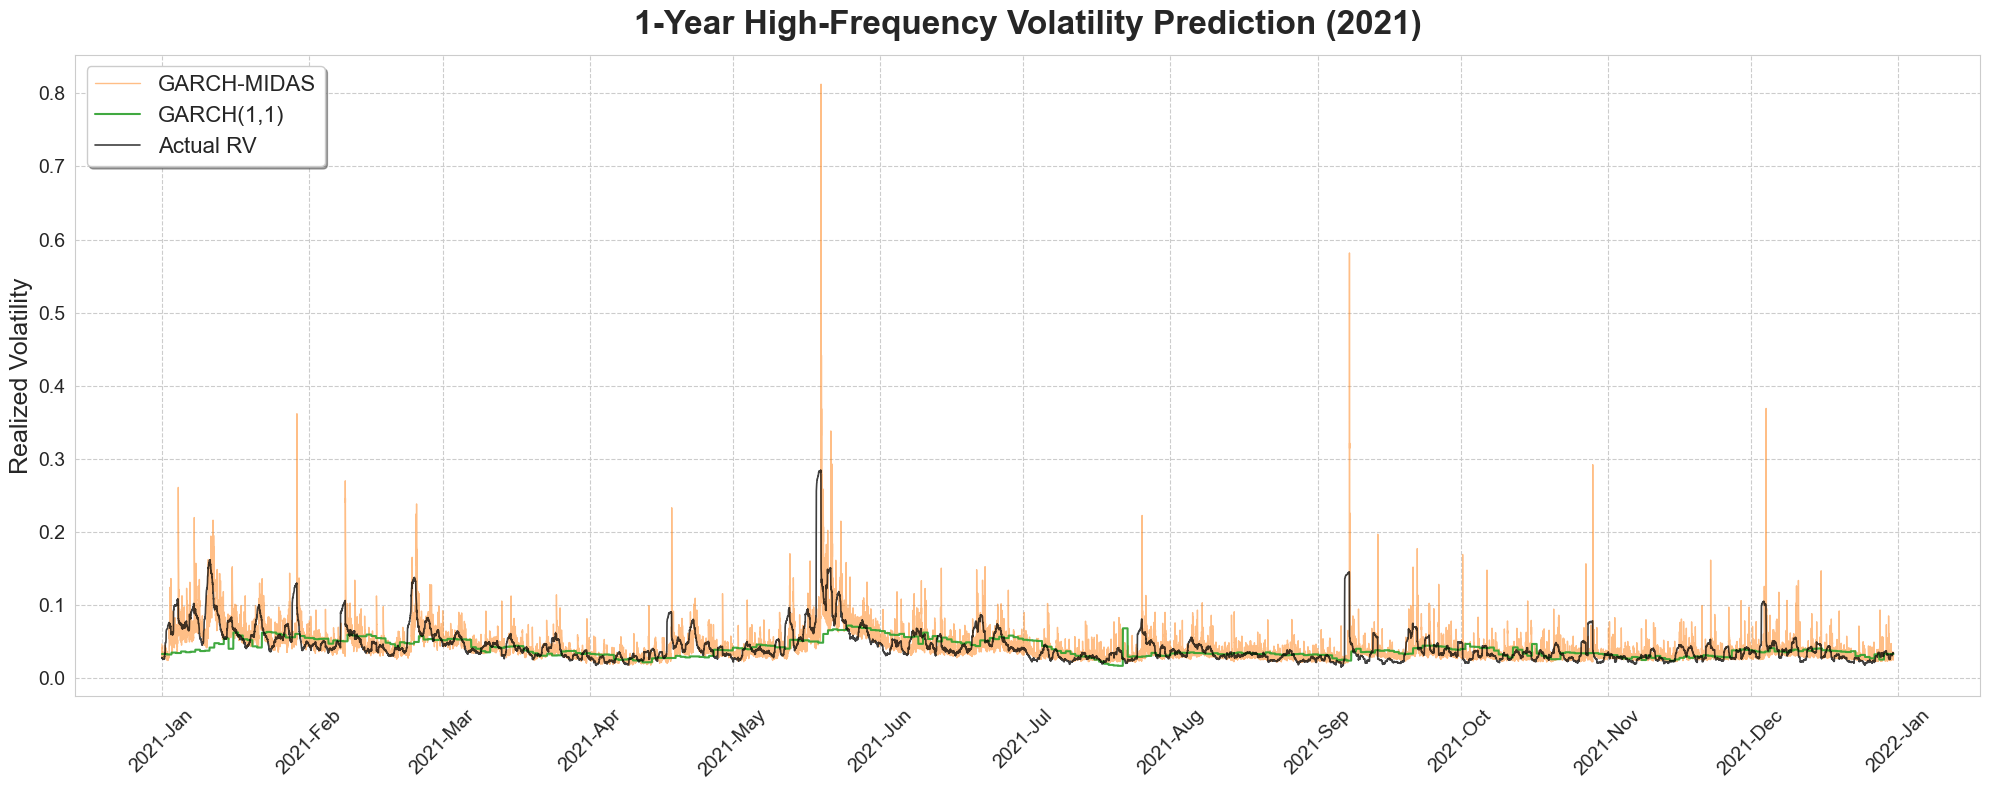

In [16]:
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})

try:
    # 1. GARCH(1,1) 파일 로드 (여기서 Actual_RV를 기준점으로 추출!)
    df_garch11 = pd.read_csv('Predictions_2021_GARCH11.csv', index_col='Datetime', parse_dates=True)
    
    # 2. GARCH-MIDAS (Benchmark) 파일 로드
    df_garch_midas = pd.read_csv('Predictions_2021_GARCH_MIDAS_Benchmark.csv', index_col='Datetime', parse_dates=True)
    
    # 2. Hybrid 모델 3가지 로드 (제일 성능 좋았던 Ridge 기준, 파일명 꼭 확인해!)
    df_hybrid_bench = pd.read_csv('Preds_Hybrid_Benchmark_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_h = pd.read_csv('Preds_Hybrid_Delta_H_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_alpha = pd.read_csv('Preds_Hybrid_Delta_Alpha_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    
    # 3. Direct AI 최악의 모델 (No_MFDFA_BI-LSTM) 파일 로드 
    # (파일명은 실제 폴더에 있는 이름과 똑같이 맞춰줘!)
    df_direct_ai = pd.read_csv('Predictions_2021_Direct_No_MFDFA_BI-LSTM.csv', index_col='Datetime', parse_dates=True)

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")
    exit()

# zoom_start = '2021-05-01'
# zoom_end = '2021-05-31'

# # # 인덱스를 기준으로 필요한 구간만 슬라이싱해서 새 DataFrame에 묶기
# df_plot = pd.DataFrame(index=df_garch11.loc[zoom_start:zoom_end].index)

# # GARCH 파일에서 실제 RV 가져오기
# df_plot['Actual_RV'] = df_garch11.loc[zoom_start:zoom_end, 'Actual_RV']
# df_plot['GARCH(1,1)'] = df_garch11.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['GARCH-MIDAS'] = df_garch_midas.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Direct_AI'] = df_direct_ai.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Benchmark'] = df_hybrid_bench.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Delta_H'] = df_hybrid_h.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha.loc[zoom_start:zoom_end, 'Predicted_RV']

df_plot = pd.DataFrame(index=df_garch11.index)

# GARCH 파일에서 실제 RV 가져오기
df_plot['Actual_RV'] = df_garch11['Actual_RV']
df_plot['GARCH(1,1)'] = df_garch11['Predicted_RV']
df_plot['GARCH-MIDAS'] = df_garch_midas['Predicted_RV']
df_plot['Direct_AI'] = df_direct_ai['Predicted_RV']
df_plot['Hybrid_Benchmark'] = df_hybrid_bench['Predicted_RV']
df_plot['Hybrid_Delta_H'] = df_hybrid_h['Predicted_RV']
df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha['Predicted_RV']

# 결측치 혹시 있으면 제거
df_plot.dropna(inplace=True)

# --- [Step 3: 포스터용 그래프 그리기] ---
fig, ax = plt.subplots(figsize=(20, 8))

# 1. GARCH-MIDAS (주황색)
# 아까 보니까 스파이크가 너무 심해서 다른 걸 가림 -> 제일 뒷단(zorder=1)으로 빼고 투명도(alpha) 줌
ax.plot(df_plot.index, df_plot['GARCH-MIDAS'], color='#ff7f0e', alpha=0.5, label='GARCH-MIDAS', linewidth=1.0, zorder=1)

# 2. GARCH(1,1) (초록색)
# 가장 얌전한 기저 추세이므로 중간단(zorder=2)에 배치
ax.plot(df_plot.index, df_plot['GARCH(1,1)'], color='#2ca02c', alpha=0.9, label='GARCH(1,1)', linewidth=1.5, zorder=2)

# 3. 실제 RV (검은색) - 네 요청 반영!
# 옅은 회색에서 찐한 검은색으로 변경. 시각적 뼈대를 잡기 위해 zorder=3으로 위로 올림
ax.plot(df_plot.index, df_plot['Actual_RV'], color='black', alpha=0.75, label='Actual RV', linewidth=1.2, zorder=3)

# # 4. Direct AI (빨간 점선)
# # 타겟 실패 사례! 엇박자로 폭주하는 걸 강조하기 위해 제일 윗단(zorder=4)에 굵게 배치
# ax.plot(df_plot.index, df_plot['Direct_AI'], color='#d62728', linestyle='--', alpha=0.9, label='Direct AI (No MF-DFA, BI-LSTM)', linewidth=2.0, zorder=4)

# # 5. [추가] Hybrid 모델들 (파란색, 보라색 계열) - 우리의 핵심 무기이므로 잘 보이게 (zorder 5~7)
# ax.plot(df_plot.index, df_plot['Hybrid_Benchmark'], color='#1f77b4', alpha=0.8, label='Hybrid (Benchmark)', linewidth=1.8, zorder=5)
# ax.plot(df_plot.index, df_plot['Hybrid_Delta_H'], color='#9467bd', alpha=0.8, label='Hybrid (MF-DFA: Delta H)', linewidth=1.8, zorder=6)
# ax.plot(df_plot.index, df_plot['Hybrid_Delta_Alpha'], color='#e377c2', alpha=0.8, label='Hybrid (MF-DFA: Delta Alpha)', linewidth=1.8, zorder=7)

# --- [Step 4: 디테일 및 꾸미기] ---
ax.set_title('1-Year High-Frequency Volatility Prediction (2021)', fontsize=24, fontweight='bold', pad=15)
ax.set_ylabel('Realized Volatility', fontsize=18)

# X축 1년치에 맞게 월(Month) 단위로 눈금 설정
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=45) # 달(Month) 글자 안 겹치게 살짝 기울이기

# 범례 설정 (순서도 직관적으로 조정)
ax.legend(fontsize=16, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()

# 해상도 깨지지 않게 저장 (원하면 주석 해제)
# plt.savefig('1Year_Volatility_Comparison.png', dpi=300)
plt.show()

In [15]:
if __name__ == "__main__":
    TARGET_YEAR = 2021
    
    EXPERIMENT_DIR = "Dropout_Smoothing"
    USE_SMOOTHING = True
    DROPOUT_RATE = 0.3
    
    ai_models = ["Ridge", "LSTM", "BI-LSTM", "GRU", "BI-GRU"]
    
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    checkpoint_file = f"{EXPERIMENT_DIR}/Live_Leaderboard_{TARGET_YEAR}.csv"
    
    completed_models = set()
    if os.path.exists(checkpoint_file):
        df_check = pd.read_csv(checkpoint_file)
        if 'Model' in df_check.columns:
            completed_models = set(df_check['Model'].values)
        print(f"\nSKip: {len(completed_models)}\n")
    
    df_10m_full = pd.concat([df_10m_2020, df_10m_2021]).sort_index()
    if df_10m_full.index.tz is not None: df_10m_full.index = df_10m_full.index.tz_localize(None)
    df_10m_full = df_10m_full[~df_10m_full.index.duplicated(keep='first')]
    df_10m_full = ohlcv_rv(df_10m_full, window=144)
    returns_decimal = df_10m_full['return'] / 100 
    df_10m_full['RV_Return'] = np.sqrt((returns_decimal**2).rolling(window=144).sum())
    # df_10m_full.dropna(subset=['RV_OHLCV'], inplace=True)    

    mfdfa_full = pd.concat([mfdfa_2020, mfdfa_2021]).sort_index()
    if mfdfa_full.index.tz is not None: mfdfa_full.index = mfdfa_full.index.tz_localize(None)
    mfdfa_full = mfdfa_full[~mfdfa_full.index.duplicated(keep='first')]
    
    mfdfa_shifted = mfdfa_full.resample('1D').last().shift(1)
    mfdfa_shifted.index = pd.to_datetime(mfdfa_shifted.index).normalize()
    df_10m_full['temp_date'] = df_10m_full.index.normalize()
    df_10m_full = df_10m_full.merge(mfdfa_shifted, left_on='temp_date', right_index=True, how='left').fillna(method='ffill').dropna()
    df_10m_full.drop(columns=['temp_date'], inplace=True)
    
    # df_10m_full['Future_Vol_24h'] = df_10m_full['RV_OHLCV'].shift(-144)
    df_10m_full['Future_Vol_24h'] = df_10m_full['RV_Return'].shift(-144)
    df_10m_full.dropna(subset=['Future_Vol_24h'], inplace=True)
    
    START_MONTH = 1
    END_MONTH = 12
    monthly_experiments = []
    for month in range(START_MONTH, END_MONTH + 1):
        test_start = pd.Timestamp(f"{TARGET_YEAR}-{month:02d}-01")
        test_end = test_start + relativedelta(months=1) - pd.Timedelta(seconds=1)
        train_start = test_start - relativedelta(months=6)
        train_end = test_start - pd.Timedelta(seconds=1)
        monthly_experiments.append({'target_month': f"{TARGET_YEAR}-{month:02d}", 'train_start': train_start, 'train_end': train_end, 'test_start': test_start, 'test_end': test_end})

    final_leaderboard = []

    print("\n" + "="*50 + "\n[Part 1] Base Statistical Models (4 Models)\n" + "="*50)
    
    daily_returns_pct = df_10m_full['return'].resample('1D').sum().dropna()
    garch11_dates, garch11_preds, garch11_actuals = [], [], []
    
    TRAIN_WINDOW_DAILY = 30 
    
    for exp in monthly_experiments:
        test_period_10m = df_10m_full.loc[exp['test_start'] : exp['test_end']].copy()
        
        test_days = test_period_10m.resample('1D').first().index.normalize()
        
        monthly_garch_preds = []
        monthly_garch_dates = []
        
        for day in test_days:
            train_start_day = day - pd.Timedelta(days=TRAIN_WINDOW_DAILY)
            train_end_day = day - pd.Timedelta(days=1)
            
            train_ret = daily_returns_pct.loc[train_start_day : train_end_day]
            
            if len(train_ret) >= 10: 
                try:
                    am = arch_model(train_ret, vol='GARCH', p=1, q=1)
                    res = am.fit(disp='off')
                    forecast = res.forecast(horizon=1)
                    pred_vol = np.sqrt(forecast.variance.values[-1, 0]) / 100
                except:
                    pred_vol = monthly_garch_preds[-1] if len(monthly_garch_preds) > 0 else 0
            else:
                pred_vol = 0
                
            monthly_garch_preds.append(pred_vol)
            monthly_garch_dates.append(day)
            
        pred_df_daily = pd.DataFrame({'garch_1d': monthly_garch_preds}, index=monthly_garch_dates)
        
        test_period_10m['temp_date'] = test_period_10m.index.normalize()
        test_period_10m = test_period_10m.merge(pred_df_daily, left_on='temp_date', right_index=True, how='left')
        test_period_10m.dropna(subset=['garch_1d', 'Future_Vol_24h'], inplace=True)
        
        garch11_dates.extend(test_period_10m.index)
        garch11_preds.extend(test_period_10m['garch_1d'].values)
        garch11_actuals.extend(test_period_10m['Future_Vol_24h'].values)

    if len(garch11_actuals) > 0:
        mse = mean_squared_error(garch11_actuals, garch11_preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(garch11_actuals, garch11_preds)
        mape = mean_absolute_percentage_error(np.array(garch11_actuals) + 1e-8, np.array(garch11_preds) + 1e-8)
        r2 = r2_score(garch11_actuals, garch11_preds)
        final_leaderboard.append({'Model': 'GARCH(1,1)', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R-Squared': r2})
        print(f"  -> GARCH(1,1) RMSE: {rmse:.4f} | R2: {r2:.4f}")
        
        df_garch11_res = pd.DataFrame({
            'Datetime': garch11_dates, 
            'Actual_RV': garch11_actuals, 
            'Predicted_RV': garch11_preds, 
            'Model_Name': 'GARCH(1,1)', 
            'Scenario': 'Benchmark'
        })
        df_garch11_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_GARCH11.csv", index=False)
    
    garch_scenarios = {"Benchmark": None, "Delta_H": "delta_H", "Delta_Alpha": "delta_alpha"}
    df_hybrid_dict = {} 
    
    for g_name, exog_col in garch_scenarios.items():
        print(f"Extracting GARCH-MIDAS ({g_name}) Data...")
        hybrid_results = []
        month_starts = df_10m_full.resample('MS').first().index
        daily_rv_all = (df_10m_full['RV_Return']**2).resample('1D').last().to_frame('rv').dropna()
        
        if exog_col is None:
            df_x_raw = pd.DataFrame(0, index=daily_rv_all.index, columns=['exog_x'])
        else:
            raw_exog = mfdfa_full[[exog_col]].resample('1D').mean().reindex(daily_rv_all.index).fillna(method='ffill').fillna(0)
            df_x_raw = pd.DataFrame(raw_exog, index=raw_exog.index, columns=[exog_col])
            
        for exp in monthly_experiments:
            train_slice = df_10m_full.loc[exp['train_start'] : exp['train_end']]
            test_slice = df_10m_full.loc[exp['test_start'] : exp['test_end']]
            if exog_col is not None:
                scaler = StandardScaler()
                train_x = df_x_raw.loc[:exp['train_end']] 
                scaler.fit(train_x)
                df_x_full = pd.DataFrame(scaler.transform(df_x_raw), index=df_x_raw.index, columns=[exog_col])
            else:
                df_x_full = df_x_raw.copy()
            try:
                pred_df = garch_midas_tuned(train_slice, test_slice, daily_rv_all, df_x_full, midas_k=BASELINE_PARAMS["GARCH_K"])
                hybrid_results.append(pred_df)
            except Exception as e:
                print(f"GARCH-MIDAS 에러 발생 ({exp['target_month']}): {e}")
            
        df_base_full = pd.concat(hybrid_results).sort_index() if hybrid_results else pd.DataFrame()
        if len(df_base_full) > 0:
            df_base_full = df_base_full[~df_base_full.index.duplicated(keep='first')]
        
        if len(df_base_full) == 0: 
            print(f"[경고] {g_name} 모형 예측 결과가 없어 건너뜁니다.")
            continue
        
        df_base_full['Future_Vol_24h'] = df_10m_full['Future_Vol_24h']

        df_base_full['gm_var'] = df_base_full['gm_vol'] ** 2
        df_base_full['Smoothed_Base_RV'] = np.sqrt(df_base_full['gm_var'].rolling(window=144).mean())
        
        df_eval = df_base_full.dropna(subset=['Future_Vol_24h', 'Smoothed_Base_RV'])
        df_eval = df_eval[df_eval.index.year == TARGET_YEAR]
        
        mse = mean_squared_error(df_eval['Future_Vol_24h'], df_eval['Smoothed_Base_RV'])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(df_eval['Future_Vol_24h'], df_eval['Smoothed_Base_RV'])
        mape = mean_absolute_percentage_error(df_eval['Future_Vol_24h']+1e-8, df_eval['Smoothed_Base_RV']+1e-8)
        r2 = r2_score(df_eval['Future_Vol_24h'], df_eval['Smoothed_Base_RV'])
        final_leaderboard.append({'Model': f'GARCH-MIDAS Only ({g_name})', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R-Squared': r2})
        print(f"  -> GARCH-MIDAS ({g_name}) RMSE: {rmse:.4f} | R2: {r2:.4f}")
        df_midas_res = pd.DataFrame({
            'Datetime': df_eval.index,
            'Actual_RV': df_eval['Future_Vol_24h'].values,
            'Predicted_RV': df_eval['Smoothed_Base_RV'].values,
            'Model_Name': f'GARCH-MIDAS_{g_name}',
            'Scenario': 'Benchmark'
        })
        df_midas_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_GARCH_MIDAS_{g_name}.csv", index=False)
        
        df_hybrid_ready = df_10m_full.copy()
        
        df_hybrid_ready = df_hybrid_ready.join(df_base_full[['gm_vol']], how='inner')
        
        df_hybrid_ready['gm_var'] = df_hybrid_ready['gm_vol'] ** 2
        
        if USE_SMOOTHING:
            df_hybrid_ready['Smoothed_Base_RV'] = np.sqrt(df_hybrid_ready['gm_var'].rolling(window=144).mean())
        else:
            df_hybrid_ready['Smoothed_Base_RV'] = df_hybrid_ready['gm_vol']
        
        df_hybrid_ready.dropna(subset=['Smoothed_Base_RV'], inplace=True)
        
        df_hybrid_ready['Base_Vol_24h'] = df_hybrid_ready['Smoothed_Base_RV']
        
        # df_hybrid_ready['Target_Residual'] =df_hybrid_ready['Future_Vol_24h'] - df_hybrid_ready['Base_Vol_24h']
        
        # df_hybrid_ready['Past_Residual'] = df_hybrid_ready['RV_OHLCV'] - df_hybrid_ready['Base_Vol_24h'].shift(144)
        
        df_hybrid_ready['Target_Residual'] =np.log(df_hybrid_ready['Future_Vol_24h']/df_hybrid_ready['Base_Vol_24h'])
        
        df_hybrid_ready['Past_Residual'] = np.log(df_hybrid_ready['RV_Return']/df_hybrid_ready['Base_Vol_24h'].shift(144))
        
        df_hybrid_ready.dropna(subset=['Target_Residual', 'Past_Residual', 'Future_Vol_24h', 'gm_vol'], inplace=True)
        df_hybrid_dict[g_name] = df_hybrid_ready

    print("\n" + "="*50 + "\n[Part 2] Direct AI Models (10 Models)\n" + "="*50)
    
    direct_feature_sets = {
        "No_MFDFA": ['RV_Return', 'return'],
        "With_MFDFA": ['RV_Return', 'return', 'delta_H', 'delta_alpha', 'alpha_0']
    }
    
    for f_name, f_cols in direct_feature_sets.items():
        print(f"\n--- Direct AI [{f_name}] ---")
        for ai_name in ai_models:
            model_id = f"Direct_{f_name}_{ai_name}"
            if model_id in completed_models:
                print(f"  -> {model_id} Already Done.")
                continue
            metrics, df_res = run_annual_oos_evaluation(monthly_experiments, df_10m_full, f_cols, ai_name, f'Direct_{f_name}', dropout_rate=DROPOUT_RATE)
            final_leaderboard.append(metrics)
            df_res.to_csv(f"{EXPERIMENT_DIR}/Predictions_{TARGET_YEAR}_Direct_{f_name}_{ai_name}.csv", index=False)
            pd.DataFrame([metrics]).to_csv(checkpoint_file, mode='a', header=not os.path.exists(checkpoint_file), index=False)

    print("\n" + "="*50 + "\n[Part 3] Hybrid AI Models (30 Models)\n" + "="*50)
    
    for g_name in garch_scenarios.keys():        
        if g_name not in df_hybrid_dict: continue
        
        print(f"\n--- Hybrid Base: GARCH-MIDAS ({g_name}) ---")

        df_hybrid_ready = df_hybrid_dict[g_name] 
        
        hybrid_feature_sets = {
            "No_MFDFA": ['RV_Return', 'return', 'Past_Residual'],
            "With_MFDFA": ['RV_Return', 'return', 'Past_Residual', 'delta_H', 'delta_alpha', 'alpha_0']
        }
        
        for f_name, f_cols in hybrid_feature_sets.items():
            print(f"  [Feature Set: {f_name}]")
            for ai_name in ai_models:
                model_id = f"Hybrid_{g_name}_{f_name}_{ai_name}"
                
                if model_id in completed_models:
                    print(f"  -> {model_id} Already Done.")
                    continue
                metrics, df_res = run_annual_oos_evaluation(monthly_experiments, df_hybrid_ready, f_cols, ai_name, f'Hybrid_{g_name}_{f_name}', dropout_rate=DROPOUT_RATE)
                final_leaderboard.append(metrics)
                df_res.to_csv(f"{EXPERIMENT_DIR}/Preds_Hybrid_{g_name}_{f_name}_{ai_name}.csv", index=False)
                pd.DataFrame([metrics]).to_csv(checkpoint_file, mode='a', header=not os.path.exists(checkpoint_file), index=False)
                
    print("\n" + "="*60 + "\nUltimate 44 Models Leaderboard\n" + "="*60)
    df_leaderboard = pd.DataFrame(final_leaderboard).reset_index(drop=True)
    print(df_leaderboard.to_markdown())
    df_leaderboard.to_csv(f"{EXPERIMENT_DIR}/Ultimate_44_Leaderboard_{TARGET_YEAR}.csv", index=False)
    print("\nAll 44 experiments completed successfully!")


SKip: 40


[Part 1] Base Statistical Models (4 Models)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38276\762868834.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_10m_full = df_10m_full.merge(mfdfa_shifted, left_on='temp_date', right_index=True, how='left').fillna(method='ffill').dropna()


  -> GARCH(1,1) RMSE: 0.0231 | R2: 0.1068
Extracting GARCH-MIDAS (Benchmark) Data...


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38276\65312709.py:225: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[['midas_rv', 'exog_x']] = merged[['midas_rv', 'exog_x']].fillna(method='ffill')


----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.170973
   - Beta  (GARCH) : 0.786388
   - m     (Const) : 1.182146  -> (m^2 used: 1.39746830)
   - Theta (RV_Wgt): 1.128875  -> (theta^2 used: 1.27435800)
   - W_Exog(exog_x): 0.100000  -> (w^2 used: 0.01000000)
[DEBUG] Predicted RV (gm_vol) Stats (Test Period):
   - Mean: 0.069727
   - Min : 0.024538
   - Max : 0.361647
   - First 5 values: [0.03152298 0.03230466 0.05745079 0.05708313 0.05306089]
------------------------------------------------------------


...

----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.137658
   - Beta  (GARCH) : 0.801232
   - m     (Const) : 2.919275  -> (m^2 used: 8.52216479)
   - Theta (RV_Wgt): 0.743892  -> (theta^2 used: 0.55337488)
   - W_Exog(delta_alpha): 1.003496  -> (w^2 used: 1.00700403)
[DEBUG] Predicted RV (gm_vol) Stats (Test Period):
   - Mean: 0.033872
   - Min : 0.022441
   - Max : 0.277286
   - First 5 values: [0.03038138 0.02897063 0.02851114 0.04116448 0.03878296]
------------------------------------------------------------


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38276\65312709.py:225: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[['midas_rv', 'exog_x']] = merged[['midas_rv', 'exog_x']].fillna(method='ffill')


----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.162908
   - Beta  (GARCH) : 0.726287
   - m     (Const) : 2.969308  -> (m^2 used: 8.81679175)
   - Theta (RV_Wgt): 0.696742  -> (theta^2 used: 0.48544898)
   - W_Exog(delta_alpha): -0.792976  -> (w^2 used: 0.62881090)
[DEBUG] Predicted RV (gm_vol) Stats (Test Period):
   - Mean: 0.033109
   - Min : 0.023311
   - Max : 0.156750
   - First 5 values: [0.0290675  0.03053778 0.03992938 0.03731685 0.03462495]
------------------------------------------------------------


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38276\65312709.py:225: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged[['midas_rv', 'exog_x']] = merged[['midas_rv', 'exog_x']].fillna(method='ffill')


----------------------------------------
[DEBUG] Optimization Result: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH (Success: True)
[DEBUG] Best Parameters:
   - Alpha (GARCH) : 0.175741
   - Beta  (GARCH) : 0.673719
   - m     (Const) : 2.649498  -> (m^2 used: 7.01983812)
   - Theta (RV_Wgt): 0.693530  -> (theta^2 used: 0.48098454)
   - W_Exog(delta_alpha): 0.345066  -> (w^2 used: 0.11907086)
[DEBUG] Predicted RV (gm_vol) Stats (Test Period):
   - Mean: 0.035287
   - Min : 0.023061
   - Max : 0.368955
   - First 5 values: [0.03151179 0.0292091  0.02762974 0.02776459 0.02674245]
------------------------------------------------------------
  -> GARCH-MIDAS (Delta_Alpha) RMSE: 0.0215 | R2: 0.2271

[Part 2] Direct AI Models (10 Models)

--- Direct AI [No_MFDFA] ---
  -> Direct_No_MFDFA_Ridge Already Done.
  -> Direct_No_MFDFA_LSTM Already Done.
  -> Direct_No_MFDFA_BI-LSTM Already Done.
  -> Direct_No_MFDFA_GRU Already Done.
  -> Direct_No_MFDFA_BI-GRU Already Done.

--- Direct AI 

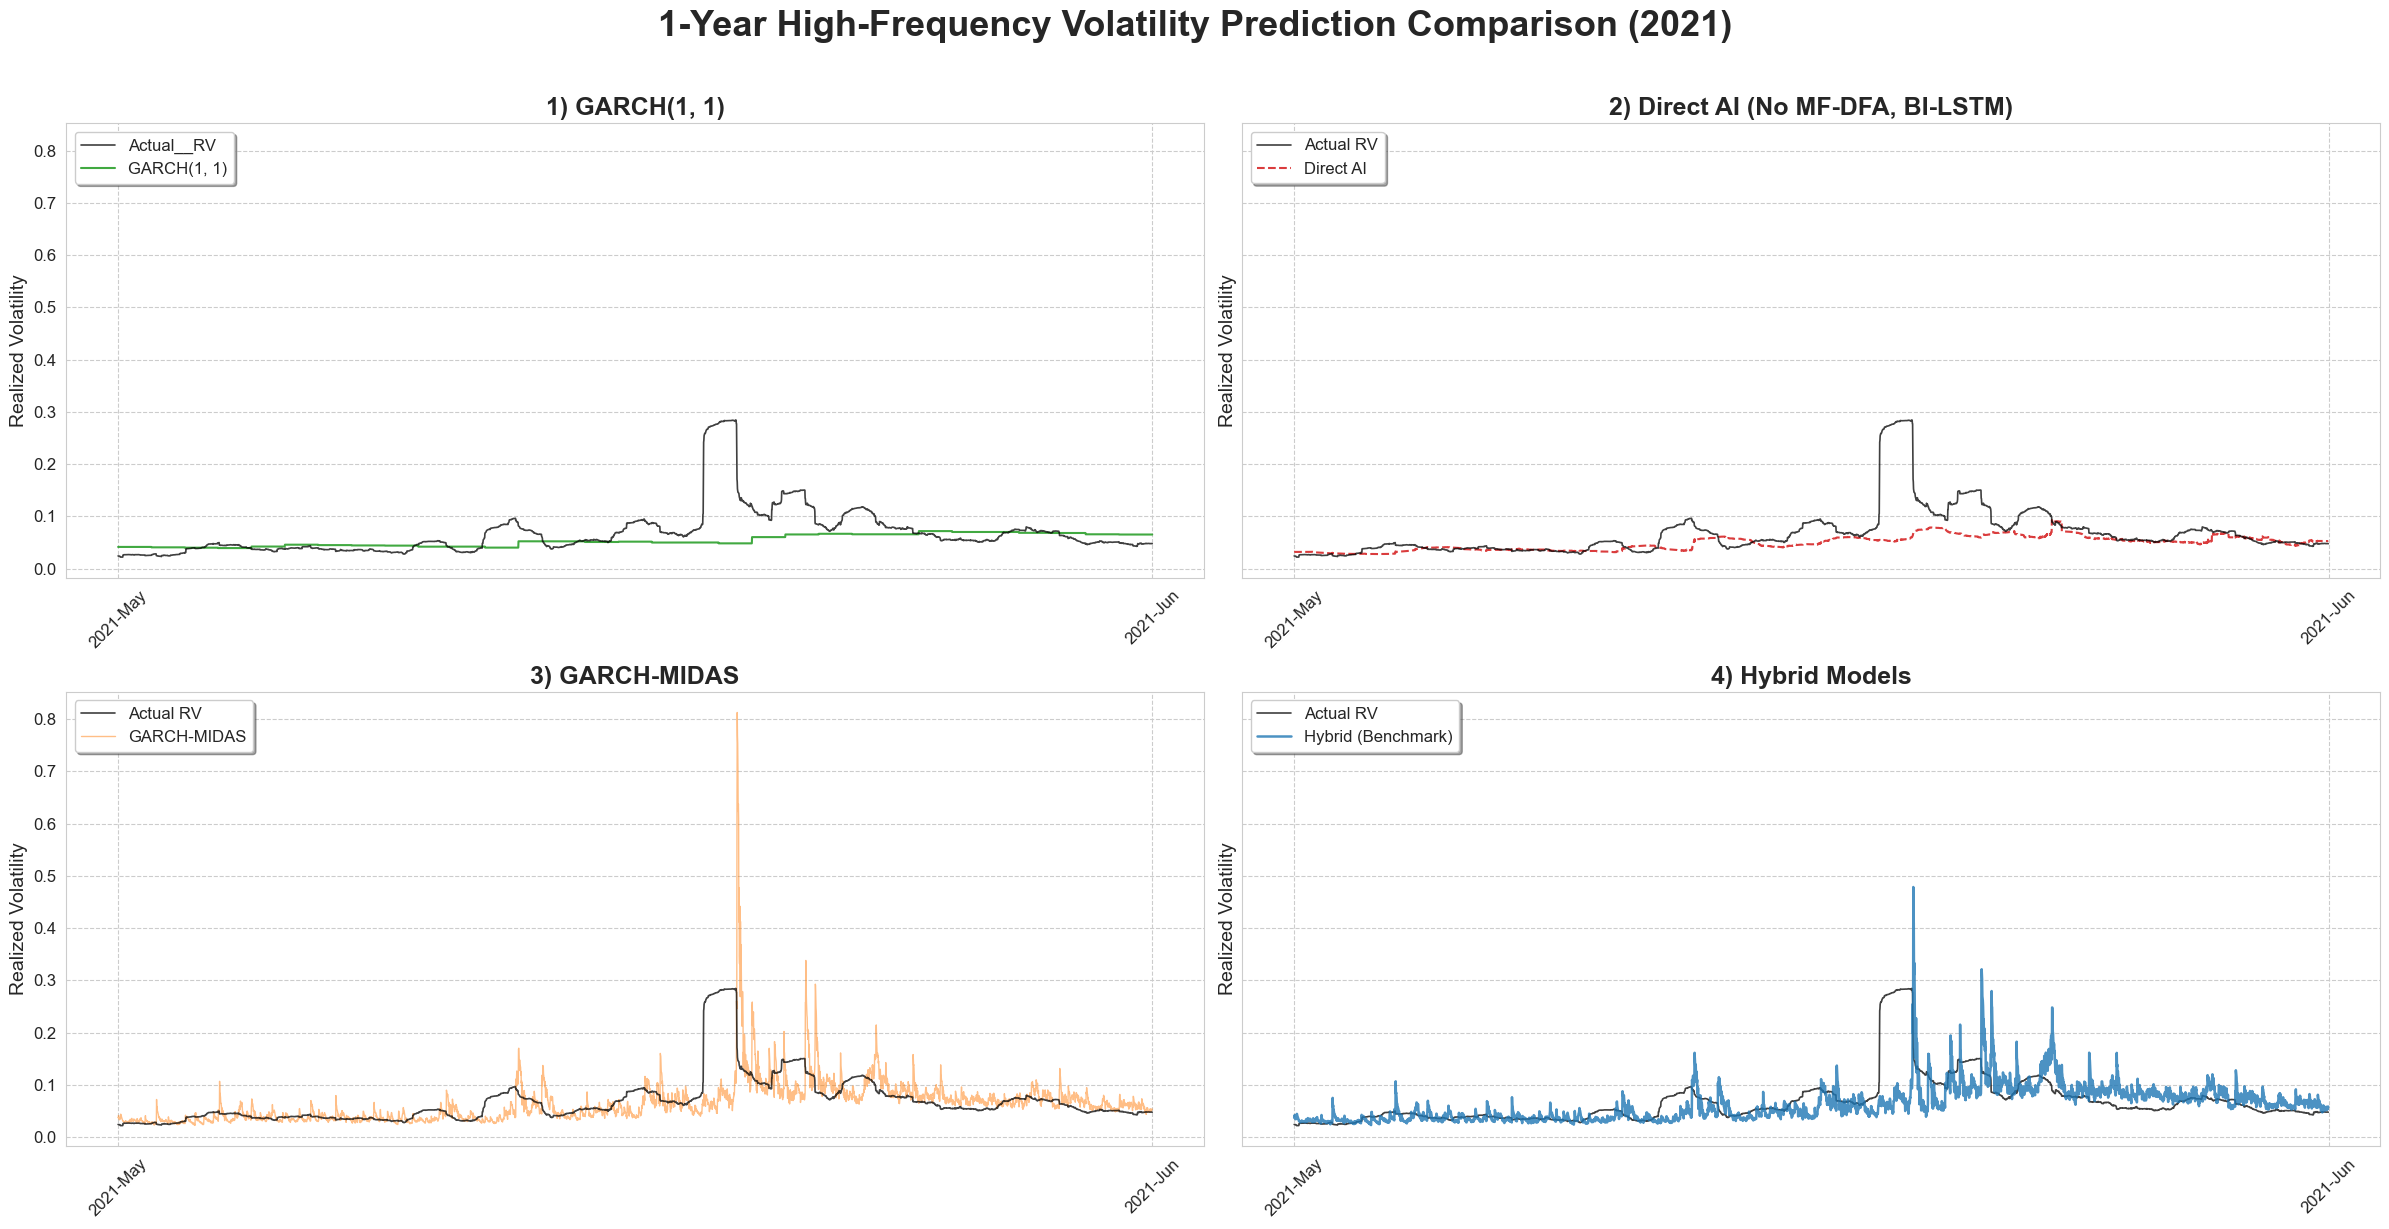

In [10]:
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})

EXPERIMENT_DIR = "No_Dropout_No_Smoothing"

try:
    # 1. GARCH(1,1) 파일 로드 (여기서 Actual_RV를 기준점으로 추출!)
    df_garch11 = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_GARCH11.csv', index_col='Datetime', parse_dates=True)
    
    # 2. GARCH-MIDAS (Benchmark) 파일 로드
    df_garch_midas = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_GARCH_MIDAS_Benchmark.csv', index_col='Datetime', parse_dates=True)
    
    # 2. Hybrid 모델 3가지 로드 (제일 성능 좋았던 Ridge 기준, 파일명 꼭 확인해!)
    df_hybrid_bench = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Benchmark_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_h = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Delta_H_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_alpha = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Delta_Alpha_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    
    # 3. Direct AI 최악의 모델 (No_MFDFA_BI-LSTM) 파일 로드 
    # (파일명은 실제 폴더에 있는 이름과 똑같이 맞춰줘!)
    df_direct_ai = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_Direct_No_MFDFA_BI-LSTM.csv', index_col='Datetime', parse_dates=True)

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")
    exit()

zoom_start = '2021-05-01'
zoom_end = '2021-05-31'

# # 인덱스를 기준으로 필요한 구간만 슬라이싱해서 새 DataFrame에 묶기
df_plot = pd.DataFrame(index=df_garch11.loc[zoom_start:zoom_end].index)

# GARCH 파일에서 실제 RV 가져오기
df_plot['Actual_RV'] = df_garch11.loc[zoom_start:zoom_end, 'Actual_RV']
df_plot['GARCH(1,1)'] = df_garch11.loc[zoom_start:zoom_end, 'Predicted_RV']
df_plot['GARCH-MIDAS'] = df_garch_midas.loc[zoom_start:zoom_end, 'Predicted_RV']
df_plot['Direct_AI'] = df_direct_ai.loc[zoom_start:zoom_end, 'Predicted_RV']
df_plot['Hybrid_Benchmark'] = df_hybrid_bench.loc[zoom_start:zoom_end, 'Predicted_RV']
df_plot['Hybrid_Delta_H'] = df_hybrid_h.loc[zoom_start:zoom_end, 'Predicted_RV']
df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha.loc[zoom_start:zoom_end, 'Predicted_RV']

# df_plot = pd.DataFrame(index=df_garch11.index)

# # GARCH 파일에서 실제 RV 가져오기
# df_plot['Actual_RV'] = df_garch11['Actual_RV']
# df_plot['GARCH(1,1)'] = df_garch11['Predicted_RV']
# df_plot['GARCH-MIDAS'] = df_garch_midas['Predicted_RV']
# df_plot['Direct_AI'] = df_direct_ai['Predicted_RV']
# df_plot['Hybrid_Benchmark'] = df_hybrid_bench['Predicted_RV']
# df_plot['Hybrid_Delta_H'] = df_hybrid_h['Predicted_RV']
# df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha['Predicted_RV']

# 결측치 혹시 있으면 제거
df_plot.dropna(inplace=True)

# --- [Step 3: 포스터용 그래프 그리기] ---
fig, axes = plt.subplots(2, 2, figsize = (24, 12), sharey = True)

ax1, ax2, ax3, ax4 = axes.flatten()

rv_color = 'black'
rv_alpha = 0.75
rv_width = 1.2

# [1] GARCH(1, 1) vs Actual RV
ax1.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual__RV', linewidth = rv_width, zorder = 3)
ax1.plot(df_plot.index, df_plot['GARCH(1,1)'], color = '#2ca02c', alpha = 0.9, label = 'GARCH(1, 1)', linewidth = 1.5, zorder = 2)
ax1.set_title('1) GARCH(1, 1)', fontsize = 18, fontweight = 'bold')

# [2] Direc AI vs Actual RV
ax2.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax2.plot(df_plot.index, df_plot['Direct_AI'], color = '#d62728', linestyle = '--', alpha = 0.9, label = 'Direct AI', linewidth = 1.5, zorder = 2)
ax2.set_title('2) Direct AI (No MF-DFA, BI-LSTM)', fontsize = 18, fontweight = 'bold')

# [3] GARCH-MIDAS vs Actual RV
ax3.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax3.plot(df_plot.index, df_plot['GARCH-MIDAS'], color = '#ff7f0e', alpha = 0.5, label = 'GARCH-MIDAS', linewidth = 1.0, zorder = 2)
ax3.set_title('3) GARCH-MIDAS', fontsize = 18, fontweight = 'bold')

# [4] Hybrid Models vs Actual RV
ax4.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax4.plot(df_plot.index, df_plot['Hybrid_Benchmark'], color = '#1f77b4', alpha = 0.8, label = 'Hybrid (Benchmark)', linewidth = 1.8, zorder = 5)
ax4.set_title('4) Hybrid Models', fontsize = 18, fontweight = 'bold')

fig.suptitle('1-Year High-Frequency Volatility Prediction Comparison (2021)', fontsize=26, fontweight='bold', y=1.02)

# 4개의 개별 그래프에 반복문을 돌면서 X축/Y축/범례 서식 일괄 적용
for ax in axes.flatten():
    ax.set_ylabel('Realized Volatility', fontsize=14)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    ax.tick_params(axis='both', labelsize=12)
    
    # X축 글자 안 겹치게 기울이기
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        
    ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()

# 해상도 깨지지 않게 저장 (원하면 주석 해제)
# plt.savefig('1Year_Volatility_2x2_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

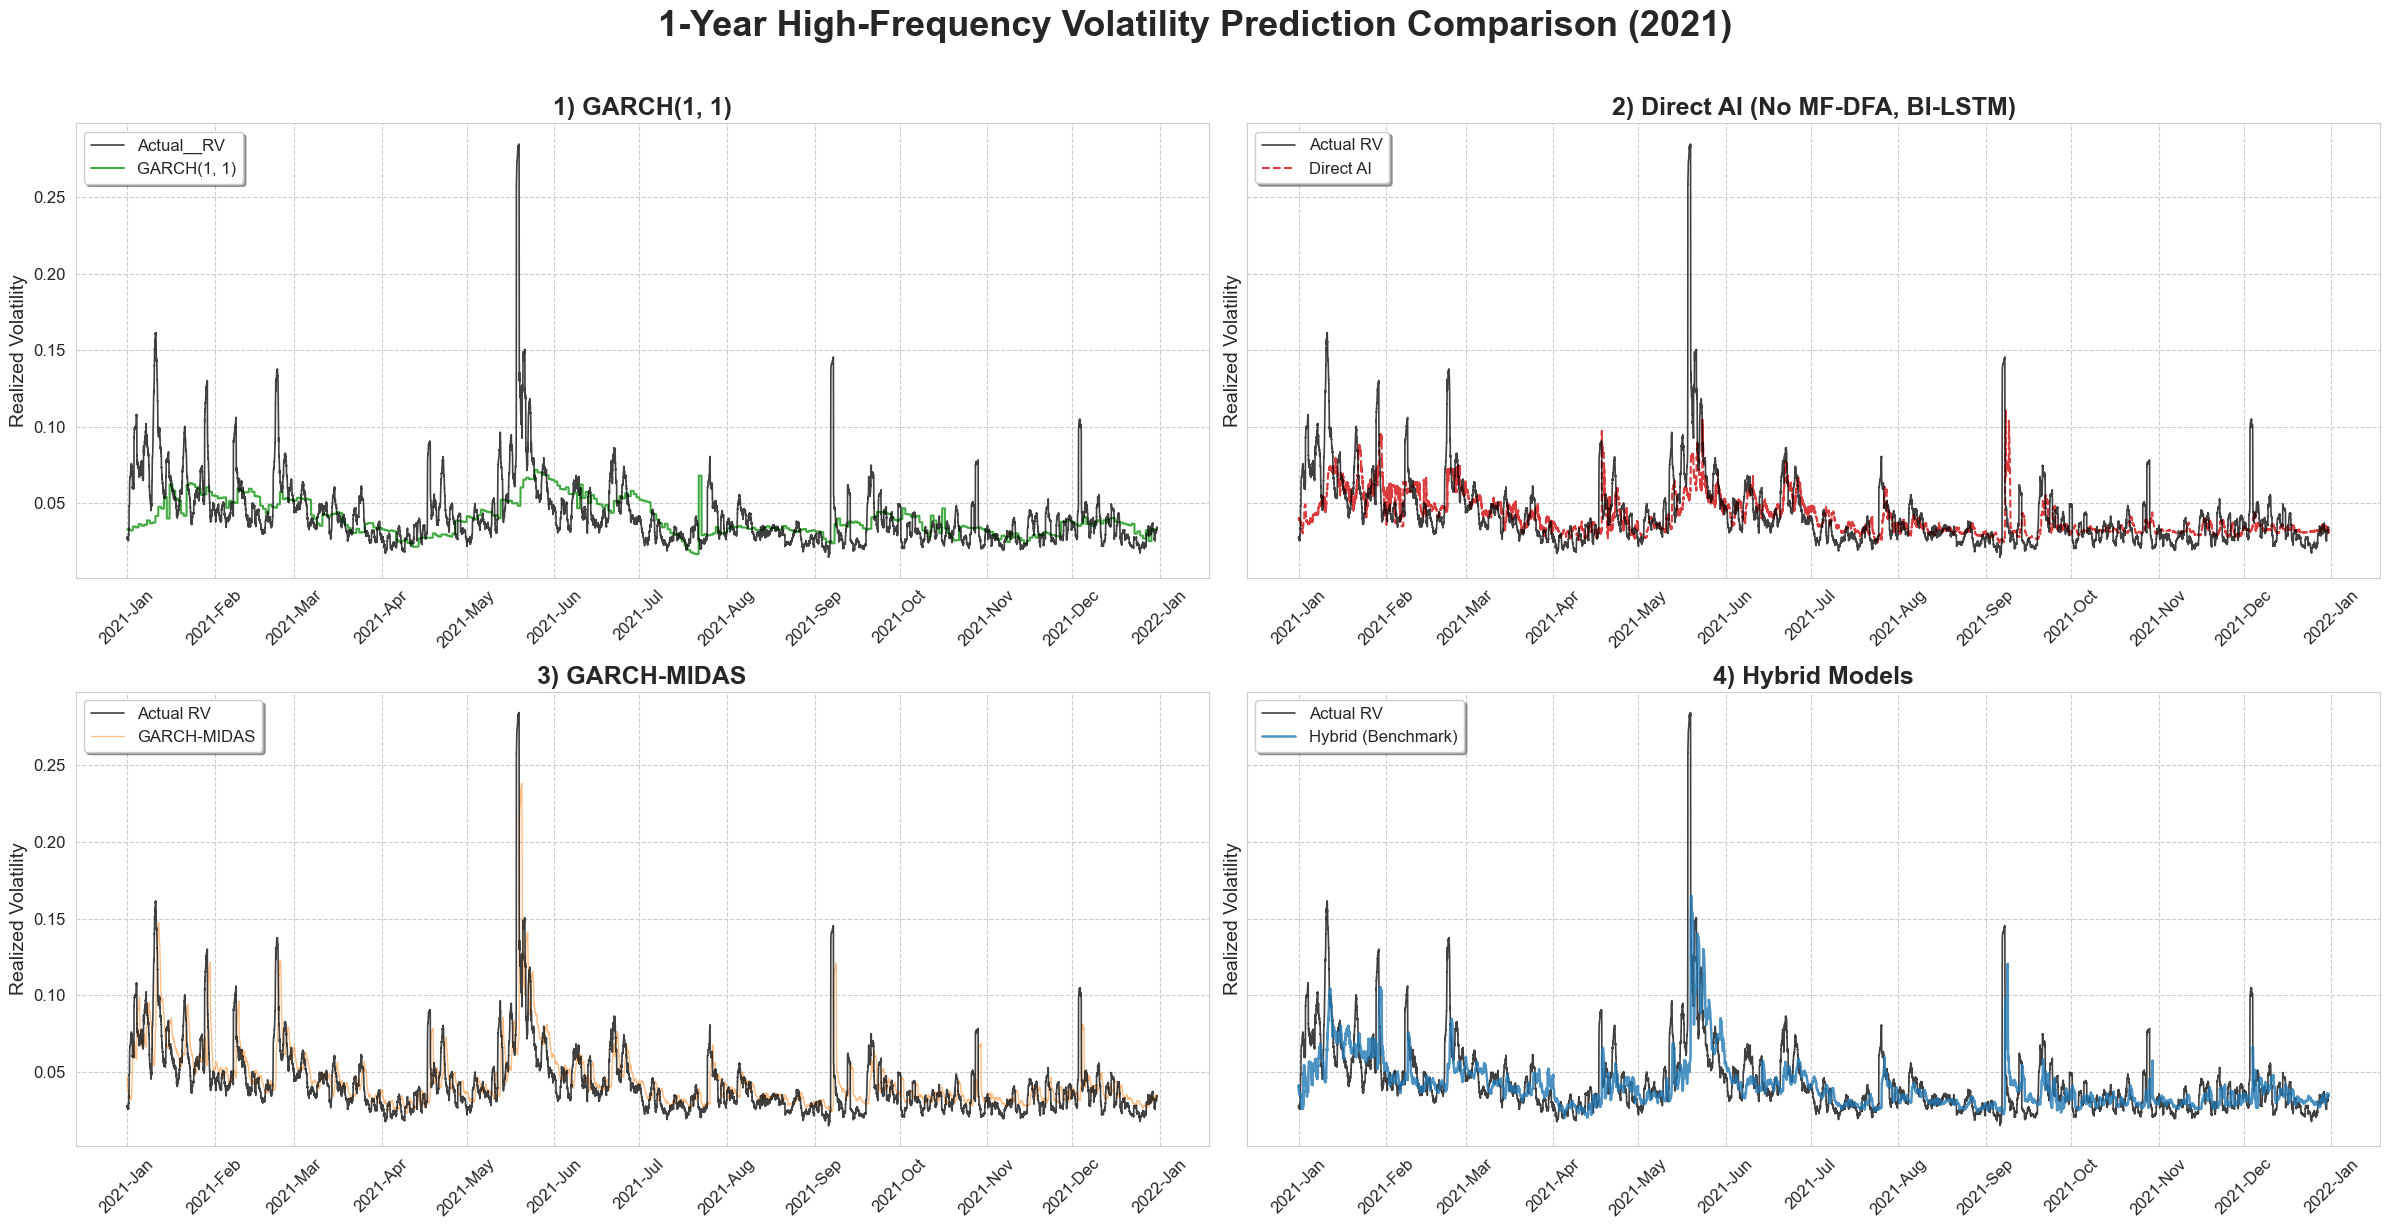

In [9]:
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})

EXPERIMENT_DIR = "Dropout_Smoothing"

try:
    # 1. GARCH(1,1) 파일 로드 (여기서 Actual_RV를 기준점으로 추출!)
    df_garch11 = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_GARCH11.csv', index_col='Datetime', parse_dates=True)
    
    # 2. GARCH-MIDAS (Benchmark) 파일 로드
    df_garch_midas = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_GARCH_MIDAS_Benchmark.csv', index_col='Datetime', parse_dates=True)
    
    # 2. Hybrid 모델 3가지 로드 (제일 성능 좋았던 Ridge 기준, 파일명 꼭 확인해!)
    df_hybrid_bench = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Benchmark_With_MFDFA_LSTM.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_h = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Delta_H_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    df_hybrid_alpha = pd.read_csv(f'{EXPERIMENT_DIR}/Preds_Hybrid_Delta_Alpha_With_MFDFA_Ridge.csv', index_col='Datetime', parse_dates=True)
    
    # 3. Direct AI 최악의 모델 (No_MFDFA_BI-LSTM) 파일 로드 
    # (파일명은 실제 폴더에 있는 이름과 똑같이 맞춰줘!)
    df_direct_ai = pd.read_csv(f'{EXPERIMENT_DIR}/Predictions_2021_Direct_No_MFDFA_BI-LSTM.csv', index_col='Datetime', parse_dates=True)

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")
    exit()

# zoom_start = '2021-05-01'
# zoom_end = '2021-05-31'

# # # 인덱스를 기준으로 필요한 구간만 슬라이싱해서 새 DataFrame에 묶기
# df_plot = pd.DataFrame(index=df_garch11.loc[zoom_start:zoom_end].index)

# # GARCH 파일에서 실제 RV 가져오기
# df_plot['Actual_RV'] = df_garch11.loc[zoom_start:zoom_end, 'Actual_RV']
# df_plot['GARCH(1,1)'] = df_garch11.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['GARCH-MIDAS'] = df_garch_midas.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Direct_AI'] = df_direct_ai.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Benchmark'] = df_hybrid_bench.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Delta_H'] = df_hybrid_h.loc[zoom_start:zoom_end, 'Predicted_RV']
# df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha.loc[zoom_start:zoom_end, 'Predicted_RV']

df_plot = pd.DataFrame(index=df_garch11.index)

# GARCH 파일에서 실제 RV 가져오기
df_plot['Actual_RV'] = df_garch11['Actual_RV']
df_plot['GARCH(1,1)'] = df_garch11['Predicted_RV']
df_plot['GARCH-MIDAS'] = df_garch_midas['Predicted_RV']
df_plot['Direct_AI'] = df_direct_ai['Predicted_RV']
df_plot['Hybrid_Benchmark'] = df_hybrid_bench['Predicted_RV']
df_plot['Hybrid_Delta_H'] = df_hybrid_h['Predicted_RV']
df_plot['Hybrid_Delta_Alpha'] = df_hybrid_alpha['Predicted_RV']

# 결측치 혹시 있으면 제거
df_plot.dropna(inplace=True)

# --- [Step 3: 포스터용 그래프 그리기] ---
fig, axes = plt.subplots(2, 2, figsize = (24, 12), sharey = True)

ax1, ax2, ax3, ax4 = axes.flatten()

rv_color = 'black'
rv_alpha = 0.75
rv_width = 1.2

# [1] GARCH(1, 1) vs Actual RV
ax1.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual__RV', linewidth = rv_width, zorder = 3)
ax1.plot(df_plot.index, df_plot['GARCH(1,1)'], color = '#2ca02c', alpha = 0.9, label = 'GARCH(1, 1)', linewidth = 1.5, zorder = 2)
ax1.set_title('1) GARCH(1, 1)', fontsize = 18, fontweight = 'bold')

# [2] Direc AI vs Actual RV
ax2.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax2.plot(df_plot.index, df_plot['Direct_AI'], color = '#d62728', linestyle = '--', alpha = 0.9, label = 'Direct AI', linewidth = 1.5, zorder = 2)
ax2.set_title('2) Direct AI (No MF-DFA, BI-LSTM)', fontsize = 18, fontweight = 'bold')

# [3] GARCH-MIDAS vs Actual RV
ax3.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax3.plot(df_plot.index, df_plot['GARCH-MIDAS'], color = '#ff7f0e', alpha = 0.5, label = 'GARCH-MIDAS', linewidth = 1.0, zorder = 2)
ax3.set_title('3) GARCH-MIDAS', fontsize = 18, fontweight = 'bold')

# [4] Hybrid Models vs Actual RV
ax4.plot(df_plot.index, df_plot['Actual_RV'], color = rv_color, alpha = rv_alpha, label = 'Actual RV', linewidth = rv_width, zorder = 3)
ax4.plot(df_plot.index, df_plot['Hybrid_Benchmark'], color = '#1f77b4', alpha = 0.8, label = 'Hybrid (Benchmark)', linewidth = 1.8, zorder = 5)
ax4.set_title('4) Hybrid Models', fontsize = 18, fontweight = 'bold')

fig.suptitle('1-Year High-Frequency Volatility Prediction Comparison (2021)', fontsize=26, fontweight='bold', y=1.02)

# 4개의 개별 그래프에 반복문을 돌면서 X축/Y축/범례 서식 일괄 적용
for ax in axes.flatten():
    ax.set_ylabel('Realized Volatility', fontsize=14)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    ax.tick_params(axis='both', labelsize=12)
    
    # X축 글자 안 겹치게 기울이기
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        
    ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()

# 해상도 깨지지 않게 저장 (원하면 주석 해제)
# plt.savefig('1Year_Volatility_2x2_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()